# KernelICL on corrupted MNIST (MNIST-C): does the head-level explanation predict what happens when the context changes?

This notebook tests the central question of *Leave No-One-Out: Context Modifications in Tabular Foundation Models* on a real tabular foundation model. **KernelICL** (the fine-tuned checkpoint `paper.pt`) predicts by a readable kernel vote over context labels (paper Eq. 4), and its embeddings move when the context changes. For every kind of context edit the paper defines, we compare the **frozen** effect (the head explanation, in closed form, embeddings held fixed) with the **recomputed** effect (rerun the model on the edited context):

| Edit | Frozen effect | Paper | Section |
|---|---|---|---|
| Row deletion | Eq. 8 | §4.1–4.2, Table 1 | 3 |
| Label replacement | $w_i(v - y_i)$ | App. C.3 | 4.1 |
| Admission (observed / pseudo-label) | Eq. 11–12 | §4.3, App. C.4 | 4.2 |
| Head-only reweighting | Eq. 13 | App. D.2, Eq. D.7 | 5 |

**Data.** MNIST-C: 94% clean digits and 6% from three rare corruptions (`translate`, `stripe`, `canny_edges`), assigned independently of the digit. Rare digits are correctly labelled and fail only because there are few of them (**under-representation**, not a shortcut). Features: the small CNN of the existing MNIST-C notebook (trained on separate clean digits), reduced to 64 dimensions per context.

**What this notebook does not repeat.** Reweighting value, tail composition, the ρ sweep, label noise and native-TabICL resampling are in `kernel_icl_leave_one_out_mnist_corrupted.ipynb`. This notebook reports accuracy only where it helps interpret an audit. It builds on the prototypes `kernel_icl.ipynb` (frozen vs refit difficulty on toy data) and `visualise_tabicl_embeddings_classifier.ipynb` (a shrinking-context animation).

### Running on Google Colab
1. *Runtime → Change runtime type*: choose a **GPU** and **high-RAM**. Every audit reruns KernelICL thousands of times.
2. Add a GitHub token as a Colab secret named `GITHUB_TOKEN`; the first cell clones and installs `interpret_tfm`. **Push local changes first.**
3. Put `paper.pt` in Google Drive and set `CHECKPOINT_PATH` (0.2).
4. Run once with `SMOKE_TEST = True` (2 seeds, small contexts), then `SMOKE_TEST = False`.
5. Section 0 must run first. Sections 2 and 3 share the deletion passes of 2.2; every other section only needs Section 0 (Section 5 also needs the refit scores of 2.2).

### Contents
0. Setup: install, configuration, helpers, checks, data, features, KernelICL, per-seed data
1. KernelICL baseline: accuracy, agreement with MLP heads, embedding map (figure 6)
2. Difficulty: frozen vs refit leave-one-out (figure 1)
3. Deletion audit (figures 2, 4, 5)
4. Label replacement and admission audits
5. Reweighting audit (Eq. 13 vs Eq. D.7)
6. GP head on KernelICL embeddings
7. Sanity-check summary
8. Decisions
9. Results summary (figure 3)
10. Interpretation

# 0. Setup

## 0.1 Install and environment

In [1]:
# Clone the (private) repository on Colab and install it: kernel_louis plus the KernelICL
# fork of tabicl. numpy / torch / scikit-learn are already in Colab and are left alone.
#
# Access: add a GitHub token as a Colab secret named GITHUB_TOKEN (key icon in the left
# sidebar, notebook access on). It is read from there and never printed or stored in
# the clone's git config.
import os
import sys
import subprocess

REPO = "github.com/AndreaKarlova/interpret_tfm.git"
BRANCH = "main"
IN_COLAB = "google.colab" in sys.modules


def git(*args, token=None):
    """Run git; on failure, raise without echoing the token-bearing command."""
    result = subprocess.run(["git", *args], capture_output=True, text=True)
    if result.returncode != 0:
        message = result.stderr.replace(token, "***") if token else result.stderr
        raise RuntimeError(f"git {args[0]} failed:\n{message}")


if IN_COLAB:
    from google.colab import userdata

    REPO_DIR = "/content/interpret_tfm"
    token = userdata.get("GITHUB_TOKEN")
    authed = f"https://x-access-token:{token}@{REPO}"
    if not os.path.isdir(REPO_DIR):
        git("clone", "-q", "-b", BRANCH, authed, REPO_DIR, token=token)
        git("-C", REPO_DIR, "remote", "set-url", "origin", f"https://{REPO}")
    else:
        git("-C", REPO_DIR, "pull", "-q", authed, BRANCH, token=token)
    del token, authed

    # Never `pip install tabicl` on top: the PyPI package would shadow the fork.
    !pip install -q -e {REPO_DIR}
    !pip install -q umap-learn  # figure 6 only
else:
    REPO_DIR = os.path.abspath("..")  # running locally from interpret_tfm/notebooks

# An editable install only takes effect after a runtime restart, so put the sources on
# the path directly as well.
for path in (os.path.join(REPO_DIR, "src"), os.path.join(REPO_DIR, "kernelicl"), REPO_DIR):
    if path not in sys.path:
        sys.path.insert(0, path)
print("using kernel_louis, kernelicl/ and tabicl from", REPO_DIR)

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for interpret_tfm (pyproject.toml) ... done
using kernel_louis, kernelicl/ and tabicl from /content/interpret_tfm


In [2]:
import time
import random
import shutil
import platform

import numpy as np
import pandas as pd
import scipy
import sklearn
import torch
import matplotlib
import matplotlib.pyplot as plt
import psutil
from IPython.display import display

pd.set_option("display.max_rows", 500)
pd.set_option("display.width", 200)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
try:
    import tabicl
    TABICL_VERSION = tabicl.__version__
except ImportError:
    TABICL_VERSION = None

print(f"python {platform.python_version()} | numpy {np.__version__} | pandas {pd.__version__} | "
      f"scipy {scipy.__version__} | scikit-learn {sklearn.__version__}")
print(f"torch {torch.__version__} | matplotlib {matplotlib.__version__} | tabicl {TABICL_VERSION}")
print(f"device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else ""))
memory = psutil.virtual_memory()
print(f"RAM: {memory.total / 2**30:.1f} GB total, {memory.available / 2**30:.1f} GB available")
if DEVICE == "cpu":
    print("WARNING: no GPU found. The audits rerun KernelICL thousands of times and will be very slow "
          "on CPU. In Colab: Runtime -> Change runtime type -> GPU.")

python 3.13.15 | numpy 2.1.3 | pandas 2.2.3 | scipy 1.16.3 | scikit-learn 1.6.1
torch 2.11.0+cu130 | matplotlib 3.10.0 | tabicl 2.1.1
device: cuda (NVIDIA A100-SXM4-40GB)
RAM: 83.5 GB total, 80.9 GB available


## 0.2 Configuration

All parameters in one place. Start with `SMOKE_TEST = True`.

In [3]:
# ----- run mode -----
SMOKE_TEST = False          # True: 2 seeds, small contexts. Set False for the full run.
USE_DRIVE = True           # keep the data, cached features and the checkpoint in Google Drive
DATA_DIR = "/content/data"
CHECKPOINT_PATH = "/content/drive/MyDrive/kernelicl/paper.pt"   # the fine-tuned KernelICL checkpoint

# ----- seeds -----
SPLIT_SEED = 12345
SEEDS = [0, 1] if SMOKE_TEST else list(range(10))

# ----- data design -----
N_CLASSES = 10
N_GROUPS = 4                     # clean + 3 rare corruptions
RARE_GROUPS = (1, 2, 3)
RARE_CORRUPTIONS = ["translate", "stripe", "canny_edges"]   # fixed: the existing MNIST-C pilot's choice
GROUP_NAMES = ["identity"] + RARE_CORRUPTIONS
N_CTX = 200 if SMOKE_TEST else 1000          # main context (fine-tuning range: <= 1,024 rows)
RHO = 0.06                                   # rare fraction: 2 per digit per corruption at n = 1,000
QUERY_DIGITS_PER_CLASS = 3 if SMOKE_TEST else 25   # each shown in all 4 versions
CANDIDATES_PER_GROUP = 5 if SMOKE_TEST else 20
N_AUDIT_COMMON = 10 if SMOKE_TEST else 60    # clean points added to the rare ones in the 3.4 / 4.1 audit set

# ----- CNN features (as in the existing MNIST-C notebook) -----
CNN_SEED = 0
CNN_EPOCHS = 1 if SMOKE_TEST else 5
CNN_LR = 1e-3
CNN_BATCH = 128
N_PCA = 64                                   # fine-tuning range: <= 100 features
SWEEP_SIZES = [N_CTX // 4, N_CTX // 2, N_CTX, 2 * N_CTX]   # 3.4; 2 * N_CTX is beyond the fine-tuning range

# ----- KernelICL -----
N_FOLDS = 5                      # gamma calibration (KernelICL protocol, kernelicl_clinical)
ACCURACY_TOLERANCE = 0.01
GP_SIGMA2_GRID = [0.01, 0.1, 1.0]
GP_GAMMA_FACTORS = np.geomspace(0.1, 1000, 13)   # GP gamma = factor / median squared distance of the embeddings
BATCH_SIZE = 8                   # edited contexts per forward pass

# ----- audit -----
SIGN_TOL = 1e-3                  # sign agreement only where |true effect| > SIGN_TOL (declared in advance)
TOP_K = 10
TAU, LAM = 0.95, 8               # pre-registered tail (Section 5)
N_DRAWS = 1 if SMOKE_TEST else 3
SCATTER_PAIRS = 5000             # random (point, query) pairs drawn in figure 2

SANITY = {}    # sanity-check results, filled in by later sections
RUN_LOG = []   # run-dependent notes

## 0.3 Helper functions

Everything reusable lives in the repository and is tested there:

| Module | Used for |
|---|---|
| `kernelicl/kernelicl_diagnostics.py` | `load_kernelicl`; `KernelICLPredictor` (predictions, weights, frozen LOO) and its **matched** edited passes (`processed`, `edited_passes`: edited contexts reuse the full context's fitted preprocessing) |
| `kernelicl/kernelicl_clinical.py` | `fold_embeddings`, `calibrate_scale` (γ by the KernelICL paper's re-embedded cross-validation), `_embed` (row-stage representation) |
| `kernel_louis.audit` | frozen effects of deletion / label replacement / admission (Eq. 8, 11), audit metrics (Eq. 10, App. C.3) |
| `kernel_louis.heads`, `loo` | `kernel_head_proba` (every frozen kernel-vote prediction), GP head, GP frozen deletion, GP hyperparameter search |
| `kernel_louis.evaluation`, `modulation` | per-group accuracy, AUC, perplexity, purity, mean ± SE; tail multipliers and resampling |
| `kernel_louis.mnist_c`, `kernel_louis.cnn` | data |

The cells below hold only the experiment-specific glue.

In [4]:
# --- Imports ---
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.special import logsumexp
from scipy.stats import spearmanr

from kernel_louis import mnist_c
from kernel_louis.cnn import train_cnn, extract_features
from kernel_louis.kernels import squared_distances, median_heuristic_gamma
from kernel_louis.heads import kernel_head_proba, gp_predict
from kernel_louis.loo import (select_gamma_loo, gp_loo_precision, gp_frozen_deletion_effects,
                              select_gp_hyperparameters_cv)
from kernel_louis.audit import (frozen_deletion_proba_log, frozen_relabel_effects,
                                frozen_admission_effects, compute_audit_metrics)
from kernel_louis.modulation import tail_multiplier, random_tail_multiplier, resample_context
from kernel_louis.evaluation import (group_accuracy_metrics, detection_auc, weight_perplexity,
                                     mean_and_se, purity)
from kernelicl_diagnostics import load_kernelicl, KernelICLPredictor
from kernelicl_clinical import GAMMA_GRID, _embed, _make_folds, calibrate_scale, fold_embeddings
from kernelicl_finetune import describe_checkpoint
from tabicl import TabICLClassifier
from threadpoolctl import threadpool_limits

# Single-threaded numpy linear algebra: on Colab, numpy's and scipy's BLAS thread pools compete with
# torch's for a few cores, which made small and medium matrix work ~10x slower in the MNIST-C notebook.
# The heavy per-deletion work runs in torch on the GPU and is unaffected.
threadpool_limits(limits=1, user_api="blas")

In [5]:
# --- General helpers ---
def set_all_seeds(seed):
    """Seed numpy's global RNG, Python's random module and torch."""
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)


def mean_se_table(summary, label_cols, metrics):
    """Readable table: label columns plus one 'mean ± SE' text column per metric."""
    table = summary[label_cols].copy()
    for metric in metrics:
        means, ses = summary[f"{metric}_mean"], summary[f"{metric}_se"]
        table[metric] = [f"{m:.3f} ± {s:.3f}" for m, s in zip(means, ses)]
    table["n_seeds"] = summary["n_seeds"]
    return table.reset_index(drop=True)


def local_copy(path, local_path=None):
    """Copy a file or folder from Google Drive to the runtime's local disk (once) and return the local path.
    Long reads through the Drive mount can drop out ("Transport endpoint is not connected"); on such an
    error Drive is remounted and the copy retried once. Paths outside Drive are returned unchanged."""
    if not path.startswith("/content/drive"):
        return path
    local_path = local_path or os.path.join("/content/local_cache", os.path.basename(path.rstrip("/")))
    if os.path.exists(local_path):
        return local_path
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    partial = local_path + ".partial"
    for attempt in range(2):
        try:
            if os.path.isdir(path):
                shutil.copytree(path, partial, dirs_exist_ok=True)
            else:
                shutil.copy(path, partial)
            break
        except OSError:
            if attempt == 1:
                raise
            from google.colab import drive
            drive.mount("/content/drive", force_remount=True)
    os.replace(partial, local_path)
    return local_path


def is_rare(groups):
    """True for points in a rare group."""
    return np.isin(groups, RARE_GROUPS)


def take(s, positions):
    """Rows `positions` of a set (a dict of equal-length arrays)."""
    return {key: value[positions] for key, value in s.items()}


def stratified_positions(keys, counts, rng):
    """Random positions with exactly counts[key] rows of each key (keys: one value per row)."""
    chosen = []
    for key, count in counts.items():
        candidates = np.where(keys == key)[0]
        assert len(candidates) >= count, f"only {len(candidates)} rows for {key}, need {count}"
        chosen.append(rng.choice(candidates, size=count, replace=False))
    return rng.permutation(np.concatenate(chosen))


def scaled_group_counts(groups, n_target):
    """Per-group counts for a smaller nested context: proportional to `groups`, rounded, >= 1 each."""
    sizes = np.bincount(groups, minlength=N_GROUPS)
    scaled = np.maximum(1, np.round(sizes * n_target / len(groups))).astype(int)
    return {k: int(min(scaled[k], sizes[k])) for k in range(N_GROUPS)}

In [6]:
# --- Data helpers (MNIST-C) ---
def draw_sets(seed, rng):
    """One seed's images: the n = 2 * N_CTX superset (main and sweep contexts nested in it), paired
    queries (each digit in all 4 versions) and admission candidates outside the main context.
    Sets are dicts of arrays (idx, y, g, version). Returns (superset, positions per size, queries, candidates)."""
    per_digit = N_CTX // N_CLASSES
    r = mnist_c.rare_per_class(per_digit, RHO, len(RARE_CORRUPTIONS))
    main_counts = [per_digit - len(RARE_CORRUPTIONS) * r] + [r] * len(RARE_CORRUPTIONS)
    superset = mnist_c.build_context(SPLITS["context"], LABELS["train"], VERSIONS, [2 * c for c in main_counts], rng)
    positions = {2 * N_CTX: np.arange(len(superset["idx"]))}
    cells = superset["y"] * N_GROUPS + superset["g"]          # exact half of every digit x group cell
    positions[N_CTX] = stratified_positions(cells, {c * N_GROUPS + k: main_counts[k]
                                                    for c in range(N_CLASSES) for k in range(N_GROUPS)}, rng)
    for n in [N_CTX // 2, N_CTX // 4]:
        parent = positions[2 * n]
        positions[n] = parent[stratified_positions(superset["g"][parent], scaled_group_counts(superset["g"][parent], n), rng)]
    queries = mnist_c.build_paired_set(np.arange(len(LABELS["test"])), LABELS["test"], VERSIONS,
                                       QUERY_DIGITS_PER_CLASS, rng)
    pool = np.setdiff1d(SPLITS["context"], superset["idx"][positions[N_CTX]])
    cand_idx = rng.choice(pool, size=CANDIDATES_PER_GROUP * N_GROUPS, replace=False)
    cand_g = np.repeat(np.arange(N_GROUPS), CANDIDATES_PER_GROUP)
    candidates = {"idx": cand_idx, "y": LABELS["train"][cand_idx], "g": cand_g, "version": np.array(VERSIONS)[cand_g]}
    return superset, positions, queries, candidates


def raw_features(s, split):
    """128-d CNN features of a set's images (split: "train" for context / candidates, "test" for queries)."""
    return extract_features(CNN, mnist_c.gather_images(MNIST_C_ROOT, split, s["idx"], s["version"]), DEVICE)


def show_image(ax, s, position, title, split="train"):
    """Draw one image of a set."""
    image = mnist_c.gather_images(MNIST_C_ROOT, split, s["idx"][position:position + 1], s["version"][position:position + 1])
    ax.imshow(image[0], cmap="gray")
    ax.set_title(title, fontsize=8)
    ax.axis("off")

In [7]:
# --- Features and KernelICL helpers ---
def fit_reduction(F_ctx, seed):
    """Standardise, then PCA to N_PCA dimensions, both fitted on the main context only."""
    scaler = StandardScaler().fit(F_ctx)
    return scaler, PCA(N_PCA, random_state=seed).fit(scaler.transform(F_ctx))


def reduce_features(reduction, F):
    """Apply a fitted (scaler, pca) reduction; float32 for TabICL."""
    scaler, pca = reduction
    return pca.transform(scaler.transform(F)).astype(np.float32)


def project(pred, E):
    """Projected KernelICL embeddings h = W E as a float64 array (drops the batch axis)."""
    return pred.head.embed(E)[0].detach().cpu().numpy().astype(np.float64)


def one_hot(y, n_classes):
    """One-hot rows of encoded labels."""
    return np.eye(n_classes)[np.asarray(y, dtype=int)]


def audited_class(y_query_enc):
    """The class whose probability every audit tracks, per query."""
    return np.asarray(y_query_enc)  # the query's true class

In [8]:
# --- Calibration (gamma, GP hyperparameters) ---
def calibrate(pred, X_ctx, y_ctx, seed, log):
    """gamma by the KernelICL protocol (stratified folds, each re-embedded with label-free validation
    queries; sparsest scale within ACCURACY_TOLERANCE of the best accuracy), and the GP head's
    (gamma_GP, sigma2) by held-out log-likelihood on the same folds. Returns (gamma, gamma_gp, sigma2)."""
    folds = _make_folds(y_ctx, N_FOLDS, 0.2, seed)
    fold_data = fold_embeddings(pred._fit, X_ctx, y_ctx, folds)
    gamma, _, _, _ = calibrate_scale(pred.head, fold_data, GAMMA_GRID, ACCURACY_TOLERANCE)
    if gamma in (GAMMA_GRID[0], GAMMA_GRID[-1]):
        log.append(f"seed {seed}: gamma = {gamma} is at the edge of GAMMA_GRID")
    gp_folds = []
    for f in fold_data:
        y_tr = f["y_ctx"][0].cpu().numpy().astype(int)
        y_val = f["clf"].y_encoder_.transform(f["y_val"])
        gp_folds.append((project(pred, f["E_train"]), project(pred, f["E_val"]),
                         one_hot(y_tr, pred.n_classes_), one_hot(y_val, pred.n_classes_)))
    # GP scales relative to the embeddings' median squared distance (their scale differs from the kernel head's)
    sq = squared_distances(gp_folds[0][0], gp_folds[0][0])
    gp_gammas = GP_GAMMA_FACTORS / np.median(sq[np.triu_indices(len(sq), k=1)])
    gamma_gp, sigma2, _ = select_gp_hyperparameters_cv(gp_folds, gp_gammas, np.array(GP_SIGMA2_GRID))
    if gamma_gp in (gp_gammas[0], gp_gammas[-1]):
        log.append(f"seed {seed}: GP gamma {gamma_gp:.3g} is at the edge of its grid")
    return gamma, gamma_gp, sigma2


def fixed_feature_gamma(X, y_enc):
    """Bandwidth for the fixed-feature control row: frozen-LOO likelihood, honest on label-free features."""
    sq = squared_distances(X, X)
    gamma_median = 1.0 / np.median(sq[np.triu_indices(len(X), k=1)])
    gammas = gamma_median * np.geomspace(1, 1e4, 25)
    return select_gamma_loo(sq, y_enc, N_CLASSES, gammas)[0]

In [9]:
# --- Full-context pass and matched edited passes ---
def full_pass(pred, X_q, X_c):
    """Probabilities, weights and projected embeddings on the full context, for queries and candidates
    (both label-free query rows), plus the preprocessed rows that edited contexts are built from."""
    m = len(X_q)
    P, W = pred.predict_proba_and_weights(X_q)
    X_qc = np.vstack([X_q, X_c])
    E_train, E_qc = pred._embed(pred.clf, X_qc)
    H_qc = project(pred, E_qc)
    ctx_rows, qc_rows, labels = pred.processed(X_qc)
    return {"P": P, "W": W, "H_ctx": project(pred, E_train), "H_q": H_qc[:m], "H_c": H_qc[m:],
            "ctx_rows": ctx_rows, "q_rows": qc_rows[:m], "c_rows": qc_rows[m:], "labels": labels}


def run_edits(pred, make_context, n_edits, handle, return_embeddings=False):
    """Run n_edits matched edited contexts, BATCH_SIZE at a time. make_context(j) builds edit j (a dict of
    rows / labels / queries); handle(j, probs) or handle(j, probs, E_train, E_test) receives each result."""
    for start in range(0, n_edits, BATCH_SIZE):
        chunk = [make_context(j) for j in range(start, min(start + BATCH_SIZE, n_edits))]
        for out in pred.edited_passes(chunk, batch_size=BATCH_SIZE, return_embeddings=return_embeddings):
            for b, local in enumerate(out[0]):
                if return_embeddings:
                    handle(start + local, out[1][b], out[2][b:b + 1], out[3][b:b + 1])
                else:
                    handle(start + local, out[1][b])


@torch.no_grad()
def gp_mean_torch(pred, E_train, E_test, Y_train, gamma, sigma2):
    """GP-head posterior mean (m, C) refitted on a context's embeddings, solved on the model's device
    in float64 (a Cholesky solve; the same estimator as kernel_louis.heads.gp_predict, much faster)."""
    H_tr = pred.head.embed(E_train)[0].double()
    H_q = pred.head.embed(E_test)[0].double()
    K = torch.exp(-gamma * torch.cdist(H_tr, H_tr) ** 2)
    K_q = torch.exp(-gamma * torch.cdist(H_q, H_tr) ** 2)
    L = torch.linalg.cholesky(K + sigma2 * torch.eye(len(K), dtype=K.dtype, device=K.device))
    Y = torch.as_tensor(Y_train, dtype=K.dtype, device=K.device)
    return (K_q @ torch.cholesky_solve(Y, L)).cpu().numpy()


def deleted(d, i, queries):
    """Matched edited context: the main context without row i, with the given query rows."""
    keep = torch.arange(len(d["labels"]), device=d["labels"].device) != i
    return {"rows": d["ctx_rows"][keep], "labels": d["labels"][keep], "queries": queries}

In [10]:
# --- Audit helpers ---
def audit_row(actual, head, **info):
    """One results row: the audit metrics (Eq. 10, App. C.3) of points x queries effect matrices.
    relative_rms is left empty (NaN) when the true effects are negligible (RMS below SIGN_TOL), and
    top_k_overlap when there are at most TOP_K edited points (the top TOP_K would be all of them)."""
    row = {**info, **compute_audit_metrics(actual, head, tol=SIGN_TOL, top_k=TOP_K)}
    if row["rms_actual"] < SIGN_TOL:
        row["relative_rms"] = np.nan
    if np.asarray(actual).shape[0] <= TOP_K:
        row["top_k_overlap"] = np.nan
    return row


def group_rows(actual, head, point_rare, query_rare, **info):
    """Audit metrics split by the edited point's group (rare / clean) and the query's group."""
    rows = []
    for point_name, point_mask in [("rare", point_rare), ("clean", ~point_rare)]:
        for query_name, query_mask in [("all", np.ones_like(query_rare)), ("rare", query_rare), ("clean", ~query_rare)]:
            if point_mask.any() and query_mask.any():
                rows.append(audit_row(actual[point_mask][:, query_mask], head[point_mask][:, query_mask],
                                      edited=point_name, query=query_name, **info))
    return rows


def coordinate(P, out_cls):
    """Probability of the audited class per query, from an (m, C) probability matrix."""
    return P[np.arange(len(out_cls)), out_cls]


def frozen_deletion_head(P, log_K, y_enc, out_cls, n_classes, rows=None):
    """Head explanation I^head_i(x) = p_D(c_x | x) - p^fr_{D^-i|D}(c_x | x) (Eq. 6), points x queries.
    The frozen deleted predictions are computed in log space (exact even when one point holds all of
    a query's weight); P is the full-context prediction, so the error is E = p^fr - p_recomputed."""
    p_fr = frozen_deletion_proba_log(log_K, y_enc, n_classes, rows)[:, np.arange(len(out_cls)), out_cls]
    return coordinate(P, out_cls)[None, :] - p_fr

In [11]:
# --- Result bookkeeping ---
METRICS = ["bias", "rms", "rms_actual", "relative_rms", "sign_agreement", "top_k_overlap"]
FIG3 = []  # figure 3 rows: one per (seed, edit, rare / clean), added by Sections 3-6


def keep_other_edits(rows, edit_prefix):
    """Figure 3 rows without those of one edit type, so that re-running a section does not duplicate them."""
    return [row for row in rows if not row["edit"].startswith(edit_prefix)]


def rms_masked(v, mask):
    """Root-mean-square of v over the masked entries."""
    return float(np.sqrt(np.mean(v[mask] ** 2)))


def fig3_rows(seed, edit, actual, head, point_rare):
    """Relative error RMS(E)/RMS(I) for rare and clean edited points (figure 3)."""
    rows = []
    for name, mask in [("rare", point_rare), ("clean", ~point_rare)]:
        if mask.any():
            rms_I = float(np.sqrt(np.mean(actual[mask] ** 2)))
            relative = float(np.sqrt(np.mean((actual[mask] - head[mask]) ** 2))) / rms_I if rms_I >= SIGN_TOL else np.nan
            rows.append({"seed": seed, "edit": edit, "points": name, "relative_rms": relative})
    return rows

In [12]:
# --- Plot helpers ---
GROUP_COLOURS = ["#8a8984", "#eb6834", "#c4441a", "#f2a65a"]


def scatter_with_diagonal(ax, x, y, colours, title, xlabel, ylabel):
    """Scatter with the y = x line (perfect agreement)."""
    ax.scatter(x, y, s=4, c=colours, alpha=0.5, linewidths=0)
    lo, hi = min(np.min(x), np.min(y)), max(np.max(x), np.max(y))
    ax.plot([lo, hi], [lo, hi], "k:", lw=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)


def legend_for_groups(ax, groups):
    """Legend with one coloured dot per group present."""
    for k in sorted(set(groups)):
        ax.scatter([], [], c=GROUP_COLOURS[k], s=12, label=GROUP_NAMES[k])
    ax.legend(fontsize=7, loc="best")

## 0.4 Formula checks (sanity check 4)

On small random data with **fixed** features, the frozen formulas must equal brute-force recomputation exactly: deletion (Eq. 5/8, also with a very sharp kernel where one point holds all of a query's weight), label replacement and admission (Eq. 11), and GP deletion. With fixed features nothing can move, so this is also the paper's negative control ($E_i = 0$, §4.2) at small scale. The notebook stops if a check fails.

In [13]:
rng = np.random.default_rng(0)
C_CHECK = min(N_CLASSES, 4)
X_s, X_q_s = rng.normal(size=(30, 3)), rng.normal(size=(8, 3))
y_s, cls_s = rng.integers(0, C_CHECK, 30), rng.integers(0, C_CHECK, 8)
for gamma_s in [0.5, 300.0]:   # 300: one point holds (numerically) all of a query's weight
    log_K_g = -gamma_s * squared_distances(X_q_s, X_s)
    P_g, _ = kernel_head_proba(log_K_g, y_s, C_CHECK)
    head_g = frozen_deletion_head(P_g, log_K_g, y_s, cls_s, C_CHECK)
    for i in range(30):
        keep = np.arange(30) != i
        P_del, _ = kernel_head_proba(log_K_g[:, keep], y_s[keep], C_CHECK)
        assert np.allclose(head_g[i], coordinate(P_g, cls_s) - coordinate(P_del, cls_s), atol=1e-10), f"deletion, gamma {gamma_s}"

log_K_s = -0.5 * squared_distances(X_q_s, X_s)
P_s, _, W_s = kernel_head_proba(log_K_s, y_s, C_CHECK, return_weights=True)
head_rel = frozen_relabel_effects(W_s, y_s, (y_s + 1) % C_CHECK, cls_s, np.arange(30))
for i in range(30):
    y_new = y_s.copy()
    y_new[i] = (y_s[i] + 1) % C_CHECK
    assert np.allclose(head_rel[i], coordinate(kernel_head_proba(log_K_s, y_new, C_CHECK)[0], cls_s) - coordinate(P_s, cls_s), atol=1e-10)

Z_s = rng.normal(size=(3, 3))
log_k_z = -0.5 * squared_distances(Z_s, X_q_s)
head_adm = frozen_admission_effects(log_k_z, logsumexp(log_K_s, axis=1), P_s, np.arange(3) % C_CHECK, cls_s)
for c in range(3):
    P_add, _ = kernel_head_proba(np.column_stack([log_K_s, log_k_z[c]]), np.append(y_s, c % C_CHECK), C_CHECK)
    assert np.allclose(head_adm[c], coordinate(P_add, cls_s) - coordinate(P_s, cls_s), atol=1e-10)

K_s, K_q_s = np.exp(-0.5 * squared_distances(X_s, X_s)), np.exp(log_K_s)
Y_s = one_hot(y_s, C_CHECK)
Q_s = gp_loo_precision(K_s, 0.1)
mu_s, _ = gp_predict(K_q_s, K_s, Y_s, sigma2=0.1)
head_gp = gp_frozen_deletion_effects(K_q_s, Q_s, Q_s @ Y_s, cls_s)
for i in range(30):
    keep = np.arange(30) != i
    mu_del, _ = gp_predict(K_q_s[:, keep], K_s[np.ix_(keep, keep)], Y_s[keep], sigma2=0.1)
    assert np.allclose(head_gp[i], coordinate(mu_s, cls_s) - coordinate(mu_del, cls_s), atol=1e-8)
SANITY["4 formula checks"] = "pass"
print("deletion, label replacement, admission and GP deletion formulas equal brute-force recomputation")

deletion, label replacement, admission and GP deletion formulas equal brute-force recomputation


## 0.5 Data and splits

MNIST-C (`kernel_louis.mnist_c`), with the index splits of the existing notebook (`SPLIT_SEED`): a CNN pool, a validation pool (unused here) and a context pool. Sanity check 1: identical labels in every folder. The rare corruptions are fixed to the existing notebook's pilot choice.

In [14]:
t0 = time.time()
if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        DATA_DIR = "/content/drive/MyDrive/mnist_c_data"
    except ImportError:
        print("USE_DRIVE = True but this is not Colab; keeping DATA_DIR =", DATA_DIR)

MNIST_C_ROOT = mnist_c.download_mnist_c(DATA_DIR)
ALL_VERSIONS = mnist_c.list_versions(MNIST_C_ROOT)
assert all(v in ALL_VERSIONS for v in ["identity"] + RARE_CORRUPTIONS), "a rare corruption folder is missing"
LABELS = mnist_c.verify_mnist_c(MNIST_C_ROOT, ALL_VERSIONS)  # sanity check 1 (asserts)
SANITY["1 labels identical across folders"] = "pass"
SPLITS = mnist_c.make_index_splits(LABELS["train"], SPLIT_SEED)
VERSIONS = ["identity"] + RARE_CORRUPTIONS      # group g = position in this list
# Images are read many times during the run: keep the four folders used here on local disk, not on Drive.
local_root = "/content/local_cache/mnist_c"
for version in VERSIONS:
    local_copy(os.path.join(MNIST_C_ROOT, version), os.path.join(local_root, version))
if MNIST_C_ROOT.startswith("/content/drive"):
    MNIST_C_ROOT = local_root
print({name: len(idx) for name, idx in SPLITS.items()}, f"({time.time() - t0:.0f}s)")

Mounted at /content/drive
MNIST-C already present at /content/drive/MyDrive/mnist_c_data/mnist_c
{'val': 5000, 'cnn': 20000, 'context': 35000} (96s)


## 0.6 CNN features

The same small CNN as in the existing MNIST-C notebook, trained once (`CNN_SEED`) on the **clean** CNN-pool digits and frozen. Its 128-d penultimate layer is the raw feature vector.

In [15]:
t0 = time.time()
set_all_seeds(CNN_SEED)
cnn_images = mnist_c.gather_images(MNIST_C_ROOT, "train", SPLITS["cnn"], np.full(len(SPLITS["cnn"]), "identity"))
CNN, CNN_HOLDOUT_ACC = train_cnn(cnn_images, LABELS["train"][SPLITS["cnn"]], seed=CNN_SEED, epochs=CNN_EPOCHS,
                                 lr=CNN_LR, batch_size=CNN_BATCH, device=DEVICE)
print(f"CNN held-out clean accuracy: {CNN_HOLDOUT_ACC:.4f} ({time.time() - t0:.0f}s)")

  epoch 1/5: last batch loss 0.113
  epoch 2/5: last batch loss 0.074
  epoch 3/5: last batch loss 0.118
  epoch 4/5: last batch loss 0.038
  epoch 5/5: last batch loss 0.042
CNN held-out clean accuracy: 0.9790 (9s)


## 0.7 Load KernelICL

Loads `paper.pt` (TabICLv2 fine-tuned on synthetic tasks with a Gaussian kernel head; not fine-tuned on this data) and prints its summary. Two checks (sanity check 5) on a random context of the real size:
* **determinism:** the same pass twice must agree to < 1e-6;
* **row-order invariance:** permuting the context rows must change predictions by < 1e-5.

If either fails (e.g. GPU nondeterminism), the notebook does **not** stop: the measured size is recorded as the **noise floor**, below which audit errors are not interpreted. The cell also times one full pass and estimates the runtime.

In [16]:
t0 = time.time()
CHECKPOINT_PATH = local_copy(CHECKPOINT_PATH)   # read the 111 MB checkpoint from local disk, not through Drive
CHECKPOINT_INFO = describe_checkpoint(CHECKPOINT_PATH)
MODEL = load_kernelicl(CHECKPOINT_PATH, device=DEVICE)
print(MODEL)
assert N_CLASSES <= MODEL.config["max_classes"] and N_PCA <= 100 and N_CTX <= 1024, "outside the checkpoint's range"
SANITY["3 checkpoint limits"] = f"pass (<= 10 classes, {N_PCA} features, {N_CTX} rows; sweep point {2 * N_CTX} rows labelled)"

rng = np.random.default_rng(0)
X_chk = rng.normal(size=(N_CTX, N_PCA)).astype(np.float32)
y_chk = rng.integers(0, N_CLASSES, N_CTX)
Xq_chk = rng.normal(size=(200, N_PCA)).astype(np.float32)
pred_chk = KernelICLPredictor(MODEL, X_chk, y_chk)
t1 = time.time()
P_chk = pred_chk.predict_proba(Xq_chk)
ONE_PASS = time.time() - t1
determinism = float(np.abs(pred_chk.predict_proba(Xq_chk) - P_chk).max())
perm = rng.permutation(N_CTX)
order = float(np.abs(KernelICLPredictor(MODEL, X_chk[perm], y_chk[perm]).predict_proba(Xq_chk) - P_chk).max())
NOISE_FLOOR = max(determinism, order)
ok = determinism < 1e-6 and order < 1e-5
SANITY["5 determinism and row-order invariance"] = (f"pass ({determinism:.1e}, {order:.1e})" if ok else
                                                   f"WARNING: noise floor {NOISE_FLOOR:.1e} (see 0.7)")
print(f"determinism {determinism:.1e}, row-order {order:.1e} -> noise floor {NOISE_FLOOR:.1e}")
passes = N_CTX + 3 * N_CTX // 10 + 2 * N_GROUPS * CANDIDATES_PER_GROUP + 3 * N_DRAWS + 2 * N_FOLDS
print(f"one pass {ONE_PASS:.2f}s; about {passes} passes per seed -> roughly "
      f"{passes * ONE_PASS * len(SEEDS) / BATCH_SIZE / 60:.0f}-{passes * ONE_PASS * len(SEEDS) / 60:.0f} min ({time.time() - t0:.0f}s)")

/content/local_cache/paper.pt
  val_loss      0.6999715545071575
  started_from  tabicl-classifier-v2-20260212.ckpt
  prior_type    graph_scm
  kernel        gaussian
  d_k           512
  steps         5000
  lr_backbone   1e-05
  lr_head       0.001
  max_features  100
  max_seq_len   1024
  size_mb       111
KernelICL(from=tabicl-classifier-v2-20260212.ckpt, kernel=gaussian, gamma=0.022097086912079608, d_model=512, d_k=512, val_loss=0.7000)
determinism 0.0e+00, row-order 3.1e-05 -> noise floor 3.1e-05
one pass 0.77s; about 1479 passes per seed -> roughly 24-190 min (7s)


## 0.8 Per-seed data

For every seed:
* **sets:** a context superset of 2 × `N_CTX`; the main context (`N_CTX`) nested in it, with exactly half of every digit × group cell; smaller sweep contexts nested in the main one (stratified by group, rounded); the queries; and admission candidates outside the main context;
* **features:** standardise, then PCA to 64, fitted on the main context and applied to every set of the seed (one feature space per seed);
* **KernelICL:** a predictor on the main context; **γ** by the KernelICL paper's protocol (5 stratified folds, each **re-embedded** with label-free validation queries; the sparsest γ within 0.01 of the best accuracy), *not* by frozen-LOO likelihood, which uses the label-leaking context embeddings; the GP head's γ_GP and σ² by held-out log-likelihood on the same folds;
* **full-context pass:** probabilities, kernel weights and projected embeddings (context, queries, candidates), the preprocessed rows that every matched edit is built from, and the full-context GP head;
* **audit set** (3.4, 4.1, end-to-end row): all rare points of the main context plus `N_AUDIT_COMMON` random clean points.

Sanity check 2 (exact context composition) is asserted inside the set builders. Every seed also checks that `kernel_head_proba` on the projected embeddings reproduces the model's own probabilities; the largest gap (float32 model vs float64 recomputation) is added to the noise floor of 0.7, since it enters every audit error.

In [17]:
def prepare_seed(seed, log):
    """Everything fixed within one seed (see the text above)."""
    rng = np.random.default_rng(seed)
    superset, positions, queries, candidates = draw_sets(seed, rng)
    F_super = raw_features(superset, "train")
    reduction = fit_reduction(F_super[positions[N_CTX]], seed)
    X_super = reduce_features(reduction, F_super)
    X_q = reduce_features(reduction, raw_features(queries, "test"))
    X_c = reduce_features(reduction, raw_features(candidates, "train"))
    main = take(superset, positions[N_CTX])
    pred = KernelICLPredictor(MODEL, X_super[positions[N_CTX]], main["y"])
    pred.gamma, gamma_gp, sigma2 = calibrate(pred, X_super[positions[N_CTX]], main["y"], seed, log)
    d = {"seed": seed, "superset": superset, "positions": positions, "main": main, "queries": queries,
         "candidates": candidates, "X_super": X_super, "X_main": X_super[positions[N_CTX]], "X_q": X_q,
         "X_c": X_c, "pred": pred, "gamma": pred.gamma, "gamma_gp": gamma_gp, "sigma2": sigma2,
         **full_pass(pred, X_q, X_c)}
    d["y_enc"] = pred.clf.y_encoder_.transform(main["y"])
    d["yq_enc"] = pred.clf.y_encoder_.transform(queries["y"])
    d["out_cls"] = audited_class(d["yq_enc"])
    d["logK_q"] = -d["gamma"] * squared_distances(d["H_q"], d["H_ctx"])
    d["rho"] = float(np.mean(is_rare(main["g"])))
    d.update(gp_full(d))
    rare_pos = np.where(is_rare(main["g"]))[0]
    common_pos = rng.choice(np.where(~is_rare(main["g"]))[0], size=N_AUDIT_COMMON, replace=False)
    d["audit_rows"] = np.sort(np.concatenate([rare_pos, common_pos]))
    return d


def gp_full(d):
    """Full-context GP head on the projected embeddings: covariances, Q = (K + sigma2 I)^-1, alpha, mean."""
    K = np.exp(-d["gamma_gp"] * squared_distances(d["H_ctx"], d["H_ctx"]))
    K_q = np.exp(-d["gamma_gp"] * squared_distances(d["H_q"], d["H_ctx"]))
    Y = one_hot(d["y_enc"], d["pred"].n_classes_)
    Q = gp_loo_precision(K, d["sigma2"])
    return {"gp_K_q": K_q, "gp_Q": Q, "gp_alpha": Q @ Y, "gp_mu": K_q @ (Q @ Y), "gp_Y": Y}

In [18]:
t0 = time.time()
SEED_DATA = {}
for seed in SEEDS:
    set_all_seeds(seed)
    SEED_DATA[seed] = prepare_seed(seed, RUN_LOG)
    d = SEED_DATA[seed]
    print(f"seed {seed}: context {d['X_main'].shape}, queries {d['X_q'].shape}, rho {d['rho']:.3f}, "
          f"gamma {d['gamma']:g} (head default {MODEL.head.gamma:.3g}), GP gamma {d['gamma_gp']:g}, "
          f"sigma2 {d['sigma2']:g} ({time.time() - t0:.0f}s)")
# The frozen predictions are recomputed from the embeddings (float64) while the full-context and
# recomputed predictions come from the model (float32); their gap enters E, so it joins the noise floor.
HEAD_RECONSTRUCTION = 0.0
for seed in SEEDS:
    d = SEED_DATA[seed]
    P_check, _ = kernel_head_proba(d["logK_q"], d["y_enc"], d["pred"].n_classes_)
    HEAD_RECONSTRUCTION = max(HEAD_RECONSTRUCTION, float(np.abs(P_check - d["P"]).max()))
assert HEAD_RECONSTRUCTION < 1e-3, "kernel_head_proba on the embeddings does not reproduce KernelICL"
NOISE_FLOOR = max(NOISE_FLOOR, HEAD_RECONSTRUCTION)
print(f"head reconstruction error {HEAD_RECONSTRUCTION:.1e} -> noise floor {NOISE_FLOOR:.1e}")
SANITY["2 exact context composition"] = "pass (asserted for every set)"

seed 0: context (1000, 64), queries (1000, 64), rho 0.060, gamma 10 (head default 0.0221), GP gamma 0.00039891, sigma2 0.01 (38s)
seed 1: context (1000, 64), queries (1000, 64), rho 0.060, gamma 10 (head default 0.0221), GP gamma 0.000830426, sigma2 0.01 (77s)
seed 2: context (1000, 64), queries (1000, 64), rho 0.060, gamma 10 (head default 0.0221), GP gamma 0.000403542, sigma2 0.01 (116s)
seed 3: context (1000, 64), queries (1000, 64), rho 0.060, gamma 10 (head default 0.0221), GP gamma 0.000385323, sigma2 0.01 (151s)
seed 4: context (1000, 64), queries (1000, 64), rho 0.060, gamma 10 (head default 0.0221), GP gamma 0.000400556, sigma2 0.01 (189s)
seed 5: context (1000, 64), queries (1000, 64), rho 0.060, gamma 10 (head default 0.0221), GP gamma 0.000416071, sigma2 0.01 (229s)
seed 6: context (1000, 64), queries (1000, 64), rho 0.060, gamma 10 (head default 0.0221), GP gamma 0.000869566, sigma2 0.01 (269s)
seed 7: context (1000, 64), queries (1000, 64), rho 0.060, gamma 10 (head defau

# 1. KernelICL baseline

How good is KernelICL on this data, and is the kernel head a faithful stand-in for an MLP head? Paper §4 / App. B.5: replacing a native head creates a different predictor, so its agreement with the native predictor must be checked. Two MLP heads on the same context and features:
* **native TabICLv2** (the original checkpoint, one ensemble member, no shuffling);
* **the fine-tuned backbone's own MLP decoder** (as in `kernel_icl.ipynb`; fine-tuning did not train it, so it may be degraded).

## 1.1 Accuracy and agreement

In [19]:
t0 = time.time()
rows_acc, rows_agree = [], []
for seed in SEEDS:
    d = SEED_DATA[seed]
    native = TabICLClassifier(n_estimators=1, norm_methods=["none"], feat_shuffle_method="none",
                              class_shuffle_method="none", device=DEVICE, random_state=seed).fit(d["X_main"], d["main"]["y"])
    predictors = {"KernelICL (kernel vote)": d["P"], "native TabICLv2 (MLP)": native.predict_proba(d["X_q"]),
                  "fine-tuned backbone, MLP decoder": d["pred"].clf.predict_proba(d["X_q"])}
    for name, P_other in predictors.items():
        metrics = group_accuracy_metrics(P_other.argmax(axis=1), d["yq_enc"], d["queries"]["g"], N_GROUPS, d["rho"],
                                         rare_groups=RARE_GROUPS)
        rows_acc.append({"seed": seed, "predictor": name, **metrics})
        if name != "KernelICL (kernel vote)":
            rows_agree.append({"seed": seed, "compared with": name,
                               "prediction_agreement": float(np.mean(P_other.argmax(1) == d["P"].argmax(1))),
                               "mean_prob_difference": float(np.mean(0.5 * np.abs(P_other - d['P']).sum(axis=1)))})
    print(f"seed {seed} done ({time.time() - t0:.0f}s)")
ACC_1 = mean_and_se(pd.DataFrame(rows_acc), ["predictor"], ["worst_group", "balanced_mean"] + [f"acc_g{k}" for k in range(N_GROUPS)])
display(mean_se_table(ACC_1, ["predictor"], ["worst_group", "balanced_mean"] + [f"acc_g{k}" for k in range(N_GROUPS)])
        .rename(columns={f"acc_g{k}": GROUP_NAMES[k] for k in range(N_GROUPS)}))
AGREE_1 = mean_and_se(pd.DataFrame(rows_agree), ["compared with"], ["prediction_agreement", "mean_prob_difference"])
display(mean_se_table(AGREE_1, ["compared with"], ["prediction_agreement", "mean_prob_difference"]))

INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.



tabicl-classifier-v2-20260212.ckpt: reconstructing file:   0%|          |  0.00B /  110MB            

tabicl-classifier-v2-20260212.ckpt: downloading bytes:           |  0.00B            

seed 0 done (4s)
seed 1 done (5s)
seed 2 done (5s)
seed 3 done (6s)
seed 4 done (6s)
seed 5 done (7s)
seed 6 done (8s)
seed 7 done (8s)
seed 8 done (9s)
seed 9 done (9s)


,predictor,worst_group,balanced_mean,identity,translate,stripe,canny_edges,n_seeds
0,KernelICL (kernel vote),0.538 ± 0.009,0.814 ± 0.005,0.981 ± 0.002,0.538 ± 0.009,0.881 ± 0.009,0.854 ± 0.012,10
1,"fine-tuned backbone, MLP decoder",0.554 ± 0.008,0.823 ± 0.004,0.982 ± 0.002,0.554 ± 0.008,0.894 ± 0.007,0.864 ± 0.012,10
2,native TabICLv2 (MLP),0.548 ± 0.007,0.821 ± 0.003,0.983 ± 0.002,0.548 ± 0.007,0.891 ± 0.006,0.864 ± 0.011,10


,compared with,prediction_agreement,mean_prob_difference,n_seeds
0,"fine-tuned backbone, MLP decoder",0.941 ± 0.003,0.299 ± 0.006,10
1,native TabICLv2 (MLP),0.939 ± 0.003,0.138 ± 0.004,10


**How to read this:** the first table gives test accuracy per group (mean ± SE over seeds) for KernelICL and the two MLP heads; worst-group accuracy is the lowest of the four groups. The second table compares KernelICL's predictions with each MLP head: the share of queries with the same predicted class, and the mean size of the probability difference (total variation ½‖Δp‖₁). High agreement with native TabICLv2 means the kernel head explains a predictor close to the native one; low agreement means the audits below describe KernelICL, not TabICLv2.

In [20]:
rows = []
for seed in SEEDS:
    d = SEED_DATA[seed]
    rows.append({"seed": seed, "gamma": d["gamma"], "head_default_gamma": MODEL.head.gamma,
                 "effective_neighbours": float(np.median(weight_perplexity(d["W"])[0])),
                 "gp_gamma": d["gamma_gp"], "gp_sigma2": d["sigma2"]})
display(pd.DataFrame(rows).round(4))
kernel_row = ACC_1[ACC_1.predictor == "KernelICL (kernel vote)"].iloc[0]
common_acc = np.mean([kernel_row[f"acc_g{k}_mean"] for k in range(N_GROUPS) if k not in RARE_GROUPS])
gap = common_acc - kernel_row["worst_group_mean"]
above_chance = kernel_row["balanced_mean_mean"] > 1.0 / N_CLASSES + 0.05
SANITY["7 baseline gap"] = ("pass" if gap >= 0.10 and above_chance else
                            f"WARNING (gap {gap:.3f}, balanced accuracy {kernel_row['balanced_mean_mean']:.3f})")
print(f"clean-group minus worst-group accuracy: {gap:.3f}")

,seed,gamma,head_default_gamma,effective_neighbours,gp_gamma,gp_sigma2
0,0,10.0,0.0221,1.0,0.0004,0.01
1,1,10.0,0.0221,1.0,0.0008,0.01
2,2,10.0,0.0221,1.0,0.0004,0.01
3,3,10.0,0.0221,1.0,0.0004,0.01
4,4,10.0,0.0221,1.0,0.0004,0.01
5,5,10.0,0.0221,1.0,0.0004,0.01
6,6,10.0,0.0221,1.0,0.0009,0.01
7,7,10.0,0.0221,1.0,0.0004,0.01
8,8,10.0,0.0221,1.0,0.0009,0.01
9,9,10.0,0.0221,1.0,0.0009,0.01


clean-group minus worst-group accuracy: 0.442


**How to read this:** `gamma` is the kernel scale chosen by the KernelICL calibration, next to the head's training default. `effective_neighbours` is the median perplexity of the kernel weights: how many context points a prediction effectively averages over. `gp_gamma` and `gp_sigma2` are the GP head's hyperparameters (Section 6). Sanity check 7 warns if KernelICL is near chance or the rare groups are not clearly harder.

## 1.2 Embedding map (figure 6)

Where does KernelICL place the rare points? Do `translate` / `stripe` / `canny_edges` digits cluster by **digit** or by **corruption**? Paper App. D.5 / F call the neighbourhood organisation of minority examples unmeasured.

The map shows **query** embeddings only: they are label-free, whereas context embeddings already contain their own labels. The table backs it with numbers: for each group, the share of each query's 10 nearest neighbours (in the full space) with the same digit and with the same group, at three stages: the 64 input features, TabICL's label-free row stage, and KernelICL's in-context embedding.

In [21]:
rows = []
for seed in SEEDS:
    d = SEED_DATA[seed]
    _, _, R = _embed(d["pred"].clf, d["X_q"], return_row_repr=True)
    stages = {"input features": d["X_q"], "row stage (label-free)": R[0, len(d["y_enc"]):].detach().cpu().numpy(),
              "KernelICL embedding": d["H_q"]}
    for stage, Z in stages.items():
        for k in range(N_GROUPS):
            mask = d["queries"]["g"] == k
            rows.append({"seed": seed, "stage": stage, "group": GROUP_NAMES[k],
                         "same_digit": purity(Z, d["yq_enc"], 10, subset=mask),
                         "same_group": purity(Z, d["queries"]["g"], 10, subset=mask)})
PURITY = mean_and_se(pd.DataFrame(rows), ["stage", "group"], ["same_digit", "same_group"])
display(mean_se_table(PURITY, ["stage", "group"], ["same_digit", "same_group"]))

,stage,group,same_digit,same_group,n_seeds
0,KernelICL embedding,canny_edges,0.864 ± 0.007,0.603 ± 0.009,10
1,KernelICL embedding,identity,0.967 ± 0.002,0.689 ± 0.004,10
2,KernelICL embedding,stripe,0.827 ± 0.008,0.652 ± 0.009,10
3,KernelICL embedding,translate,0.520 ± 0.008,0.511 ± 0.008,10
4,input features,canny_edges,0.872 ± 0.006,0.830 ± 0.004,10
5,input features,identity,0.917 ± 0.003,0.651 ± 0.006,10
6,input features,stripe,0.846 ± 0.006,0.995 ± 0.001,10
7,input features,translate,0.487 ± 0.007,0.594 ± 0.006,10
8,row stage (label-free),canny_edges,0.856 ± 0.006,0.818 ± 0.005,10
9,row stage (label-free),identity,0.910 ± 0.002,0.642 ± 0.007,10


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


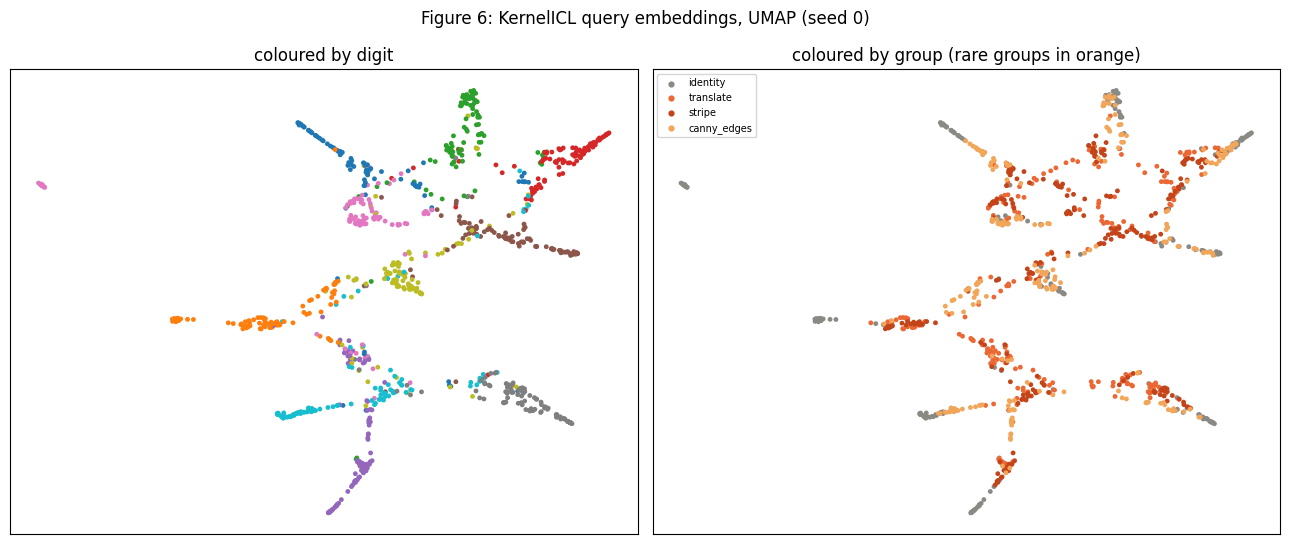

In [22]:
d = SEED_DATA[SEEDS[0]]
try:
    from umap import UMAP
    coords, method = UMAP(n_components=2, random_state=0).fit_transform(d["H_q"]), "UMAP"
except ImportError:
    coords, method = PCA(2).fit_transform(d["H_q"]), "PCA (umap-learn not installed)"
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
labels_by_cls = d["queries"]["y"]
axes[0].scatter(coords[:, 0], coords[:, 1], c=labels_by_cls, cmap="tab10", s=6)
axes[0].set_title(f"coloured by digit")
axes[1].scatter(coords[:, 0], coords[:, 1], c=[GROUP_COLOURS[k] for k in d["queries"]["g"]], s=6)
legend_for_groups(axes[1], d["queries"]["g"])
axes[1].set_title("coloured by group (rare groups in orange)")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"Figure 6: KernelICL query embeddings, {method} (seed {d['seed']})")
plt.tight_layout()
plt.show()

**How to read this:** each dot is a test query, placed by its KernelICL embedding (UMAP distorts distances, so read clusters, not exact positions). If the rare groups (orange) sit inside the clusters of their digit (left panel), the model organises by digit; if they form their own clusters, it organises by corruption. The table is the evidence: compare `same_digit` and `same_group` for the rare groups across the three stages, to see whether the in-context stage changes the organisation.

# 2. Difficulty: frozen vs refit leave-one-out (replication on real data)

* **Frozen** $L_i = 1 - p^{\mathrm{fr},-i}(y_i)$ (Eq. 9): drop point i's own vote and renormalise, embeddings fixed. Free.
* **Refit** $L_i^{\mathrm{rec}} = 1 - p_{\mathcal D^{-i}}(y_i \mid x_i)$ (Eq. 1): delete row i, rerun KernelICL (matched preprocessing), predict $x_i$ as a query. One pass per point.

`kernel_icl.ipynb` showed on 48 toy points that the frozen score collapses (as −log p: median 0.008 vs 0.19 refit) because each context embedding already contains its own label: the paper's warning that $L_i$ "is not a label-honest held-out loss" (§4.1). **New here:** real data, rare vs clean groups, seeds.

The passes of 2.2 are also Section 3's recomputed deletions and Section 6's GP refits: each pass returns predictions for $x_i$ and for every query, and its embeddings are used once (for the GP head) and discarded.

## 2.1 Frozen scores

In [23]:
for seed in SEEDS:
    d = SEED_DATA[seed]
    d["L_frozen"] = 1.0 - d["pred"].loo_proba("frozen")
print("frozen L_i computed (free: one context-on-context weight matrix per seed)")

frozen L_i computed (free: one context-on-context weight matrix per seed)


## 2.2 Matched deletion passes (shared with Sections 3 and 6)

For each context point i: the main context without row i, with queries $[x_i;$ test queries$]$, through KernelICL with the full context's fitted preprocessing. Stored per seed: $p_{\mathcal D^{-i}}(y_i \mid x_i)$, the recomputed audited probability for every query, and the GP head refitted on the recomputed embeddings (same γ_GP, σ²).

In [24]:
def deletion_audit_passes(d):
    """All matched single deletions of the main context (see the text above)."""
    n, m, n_classes = len(d["y_enc"]), len(d["yq_enc"]), d["pred"].n_classes_
    rec = {"p_self": np.zeros(n), "coord": np.zeros((n, m)), "gp_coord": np.zeros((n, m)),
           "tv_actual": np.zeros((n, m)), "tv_error": np.zeros((n, m))}
    # Frozen deleted predictions for every point at once (Eq. 5, stable): reused by Section 3.1.
    P_fr = frozen_deletion_proba_log(d["logK_q"], d["y_enc"], n_classes)
    rec["p_fr_coord"] = P_fr[:, np.arange(m), d["out_cls"]]

    def make(i):
        return deleted(d, i, torch.cat([d["ctx_rows"][i:i + 1], d["q_rows"]]))

    def handle(i, probs, E_train, E_test):
        keep = np.arange(n) != i
        rec["p_self"][i] = probs[0, d["y_enc"][i]]
        rec["coord"][i] = coordinate(probs[1:], d["out_cls"])
        rec["tv_actual"][i] = 0.5 * np.abs(d["P"] - probs[1:]).sum(axis=1)
        rec["tv_error"][i] = 0.5 * np.abs(P_fr[i] - probs[1:]).sum(axis=1)  # E vector = p_fr - p_rec
        mu = gp_mean_torch(d["pred"], E_train, E_test[:, 1:], d["gp_Y"][keep], d["gamma_gp"], d["sigma2"])
        rec["gp_coord"][i] = coordinate(mu, d["out_cls"])

    run_edits(d["pred"], make, n, handle, return_embeddings=True)
    return rec


t0 = time.time()
for seed in SEEDS:
    d = SEED_DATA[seed]
    d["rec"] = deletion_audit_passes(d)
    d["L_refit"] = 1.0 - d["rec"]["p_self"]
    print(f"seed {seed}: {len(d['y_enc'])} deletions ({time.time() - t0:.0f}s)")

seed 0: 1000 deletions (38s)
seed 1: 1000 deletions (75s)
seed 2: 1000 deletions (112s)
seed 3: 1000 deletions (149s)
seed 4: 1000 deletions (187s)
seed 5: 1000 deletions (224s)
seed 6: 1000 deletions (261s)
seed 7: 1000 deletions (298s)
seed 8: 1000 deletions (335s)
seed 9: 1000 deletions (373s)


## 2.3 Results (figure 1)

In [25]:
rows = []
for seed in SEEDS:
    d = SEED_DATA[seed]
    rare = is_rare(d["main"]["g"])
    rows.append({"seed": seed, "auc_frozen": detection_auc(d["L_frozen"], rare),
                 "auc_refit": detection_auc(d["L_refit"], rare),
                 "spearman_frozen_refit": spearmanr(d["L_frozen"], d["L_refit"])[0],
                 "median_frozen": float(np.median(d["L_frozen"])), "median_refit": float(np.median(d["L_refit"])),
                 "max_frozen": float(np.max(d["L_frozen"]))})
DIFF_2 = pd.DataFrame(rows)
cols = ["auc_frozen", "auc_refit", "spearman_frozen_refit", "median_frozen", "median_refit", "max_frozen"]
DIFF_2["all"] = "all seeds"
display(mean_se_table(mean_and_se(DIFF_2, ["all"], cols), ["all"], cols))

,all,auc_frozen,auc_refit,spearman_frozen_refit,median_frozen,median_refit,max_frozen,n_seeds
0,all seeds,0.468 ± 0.006,0.626 ± 0.013,0.006 ± 0.012,0.000 ± 0.000,0.000 ± 0.000,0.400 ± 0.163,10


**How to read this:** `auc_*` is the probability that a random rare context point scores higher than a random clean one (0.5 = no information), for each score. `spearman_frozen_refit` says whether the two scores rank points alike. `median_frozen` near 0 with a much larger `median_refit` is the label-leak collapse: the frozen score says almost every point is predicted perfectly by the others.

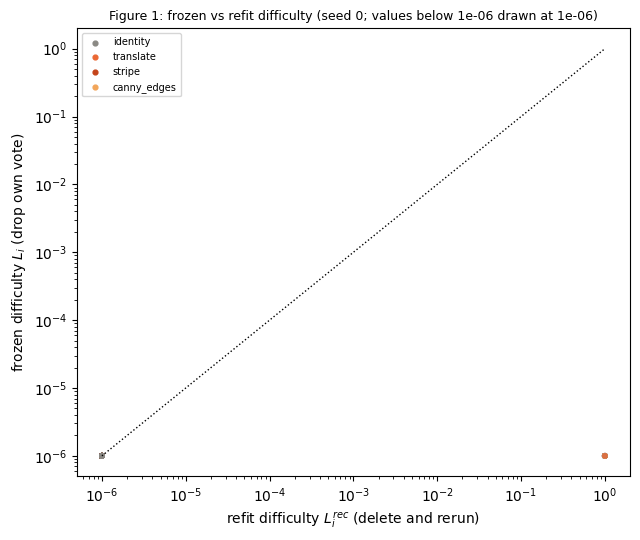

In [26]:
d = SEED_DATA[SEEDS[0]]
fig, ax = plt.subplots(figsize=(6.5, 5.5))
floor = 1e-6
ax.scatter(np.maximum(d["L_refit"], floor), np.maximum(d["L_frozen"], floor),
           c=[GROUP_COLOURS[k] for k in d["main"]["g"]], s=10, alpha=0.7)
lo = floor
ax.plot([lo, 1], [lo, 1], "k:", lw=1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("refit difficulty $L_i^{rec}$ (delete and rerun)")
ax.set_ylabel("frozen difficulty $L_i$ (drop own vote)")
legend_for_groups(ax, d["main"]["g"])
ax.set_title(f"Figure 1: frozen vs refit difficulty (seed {d['seed']}; values below {floor:g} drawn at {floor:g})", fontsize=9)
plt.tight_layout()
plt.show()

**How to read this:** one dot per context point, coloured by group. Points on the dotted line have equal frozen and refit difficulty. Points far below it are where the frozen score claims the point is easy although the model, rerun without it, finds it hard. Whether the rare points (orange) still sit to the right (hard under refit) tells you whether the honest score finds them.

# 3. Deletion audit (paper §4.1–4.2, Eq. 5–10, Table 1)

For each context point i and query x: the head explanation $I^{\mathrm{head}}_i(x) = f_{\mathcal D}(x) - f^{\mathrm{fr}}_{\mathcal D^{-i}|\mathcal D}(x)$ (Eq. 6, closed form via Eq. 8), the true influence $I_i(x) = f_{\mathcal D}(x) - f_{\mathcal D^{-i}}(x)$ (Eq. 2, from the passes of 2.2), and the error $E_i = I_i - I^{\mathrm{head}}_i$ (Eq. 7).

**Audited output:** the probability of the query's **true class** (signed). Secondary: the total-variation size ½‖·‖₁ of the full change vectors. Sign agreement counts only effects with $|I_i| > 10^{-3}$ (declared in advance); top-k overlap compares the 10 context points with the largest $|I|$ and $|I^{\mathrm{head}}|$ per query.

## 3.1 Audit metrics, with the fixed-feature control and the end-to-end row

In [27]:
def kernelicl_deletion_effects(d):
    """(I, I_head): true and frozen deletion effects, points x queries, on the audited coordinate."""
    p_D = coordinate(d["P"], d["out_cls"])[None, :]
    return p_D - d["rec"]["coord"], p_D - d["rec"]["p_fr_coord"]   # frozen predictions from 2.2


def fixed_feature_control(d):
    """The same audit for a kernel head on the fixed 64-d input features, on the audit set: frozen and
    recomputed (brute-force) deletion use the same kernel, so E must be 0 (sanity check 6)."""
    gamma = fixed_feature_gamma(d["X_main"].astype(np.float64), d["y_enc"])
    log_K = -gamma * squared_distances(d["X_q"].astype(np.float64), d["X_main"].astype(np.float64))
    P, _ = kernel_head_proba(log_K, d["y_enc"], d["pred"].n_classes_)
    rows = d["audit_rows"]
    I = np.zeros((len(rows), len(d["yq_enc"])))
    for r, i in enumerate(rows):
        keep = np.arange(len(d["y_enc"])) != i
        I[r] = coordinate(P, d["out_cls"]) - coordinate(kernel_head_proba(log_K[:, keep], d["y_enc"][keep], d["pred"].n_classes_)[0], d["out_cls"])
    return I, frozen_deletion_head(P, log_K, d["y_enc"], d["out_cls"], d["pred"].n_classes_, rows=rows)


def end_to_end_effects(d):
    """True deletion effects on the audit set with TabICL's preprocessing REFITTED on each reduced context
    (what kernelicl_diagnostics' refit mode does): an end-to-end audit, labelled as such (paper §4.2)."""
    rows = d["audit_rows"]
    contexts = []
    for i in rows:
        keep = np.arange(len(d["y_enc"])) != i
        clf = d["pred"]._fit(d["X_main"][keep], d["main"]["y"][keep])     # preprocessing refitted
        X_t, y_t = d["pred"]._tensors(clf, d["X_q"])
        k = len(y_t[0])
        contexts.append({"rows": X_t[0, :k], "labels": y_t[0], "queries": X_t[0, k:]})
    I = np.zeros((len(rows), len(d["yq_enc"])))

    def handle(r, probs):
        I[r] = coordinate(d["P"], d["out_cls"]) - coordinate(probs, d["out_cls"])

    run_edits(d["pred"], lambda r: contexts[r], len(rows), handle)   # forward passes batched
    return I

In [28]:
t0 = time.time()
ROWS_3 = []
FIG3 = keep_other_edits(FIG3, "deletion")
for seed in SEEDS:
    d = SEED_DATA[seed]
    I, I_head = kernelicl_deletion_effects(d)
    d["I"], d["I_head"] = I, I_head
    rare = is_rare(d["main"]["g"])
    ROWS_3.append(audit_row(I, I_head, seed=seed, row="KernelICL, matched (all points)"))
    I_ff, I_head_ff = fixed_feature_control(d)
    d["I_ff"], d["I_head_ff"] = I_ff, I_head_ff
    ROWS_3.append(audit_row(I_ff, I_head_ff, seed=seed, row="fixed-feature control (audit set)"))
    a = d["audit_rows"]
    ROWS_3.append(audit_row(I[a], I_head[a], seed=seed, row="KernelICL, matched (audit set)"))
    ROWS_3.append(audit_row(end_to_end_effects(d), I_head[a], seed=seed, row="KernelICL, end-to-end (audit set)"))
    FIG3 += fig3_rows(seed, "deletion", I, I_head, rare)
    print(f"seed {seed} done ({time.time() - t0:.0f}s)")

control_error = 0.0
for s in SEEDS:
    control_error = max(control_error, float(np.abs(SEED_DATA[s]["I_ff"] - SEED_DATA[s]["I_head_ff"]).max()))
# E is 0 algebraically and the frozen predictions are computed stably in log space, so only float
# rounding remains; 1e-6 is far below any effect the audit interprets (>= 1e-3).
assert control_error < 1e-6, f"fixed-feature control: |E| = {control_error:.1e}, expected 0 (up to rounding)"
SANITY["6 fixed-feature control E = 0"] = f"pass (max |E| = {control_error:.1e})"
SUMMARY_3 = mean_and_se(pd.DataFrame(ROWS_3), ["row"], METRICS)
display(mean_se_table(SUMMARY_3, ["row"], METRICS))
print(f"noise floor (0.7): {NOISE_FLOOR:.1e}: errors of this size are not interpreted")

seed 0 done (8s)
seed 1 done (15s)
seed 2 done (22s)
seed 3 done (30s)
seed 4 done (37s)
seed 5 done (44s)
seed 6 done (52s)
seed 7 done (59s)
seed 8 done (66s)
seed 9 done (74s)


,row,bias,rms,rms_actual,relative_rms,sign_agreement,top_k_overlap,n_seeds
0,"KernelICL, end-to-end (audit set)",0.001 ± 0.000,0.060 ± 0.002,0.062 ± 0.002,0.965 ± 0.004,0.496 ± 0.023,0.651 ± 0.003,10
1,"KernelICL, matched (all points)",0.000 ± 0.000,0.047 ± 0.003,0.047 ± 0.003,0.988 ± 0.002,0.511 ± 0.028,0.559 ± 0.003,10
2,"KernelICL, matched (audit set)",0.001 ± 0.000,0.060 ± 0.002,0.062 ± 0.002,0.965 ± 0.004,0.497 ± 0.023,0.650 ± 0.003,10
3,fixed-feature control (audit set),0.000 ± 0.000,0.000 ± 0.000,0.018 ± 0.000,0.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000,10


noise floor (0.7): 1.2e-04: errors of this size are not interpreted


In [29]:
rows = []
for seed in SEEDS:
    d = SEED_DATA[seed]
    rows.append({"seed": seed, "rms_tv_actual": float(np.sqrt(np.mean(d["rec"]["tv_actual"] ** 2))),
                 "rms_tv_error": float(np.sqrt(np.mean(d["rec"]["tv_error"] ** 2)))})
TV_3 = pd.DataFrame(rows)
TV_3["relative_rms_tv"] = TV_3["rms_tv_error"] / TV_3["rms_tv_actual"]
TV_3["all"] = "all points"
print("Secondary output: total-variation size of the change vectors (all classes at once)")
display(mean_se_table(mean_and_se(TV_3, ["all"], ["rms_tv_actual", "rms_tv_error", "relative_rms_tv"]),
                      ["all"], ["rms_tv_actual", "rms_tv_error", "relative_rms_tv"]))

Secondary output: total-variation size of the change vectors (all classes at once)


,all,rms_tv_actual,rms_tv_error,relative_rms_tv,n_seeds
0,all points,0.056 ± 0.003,0.056 ± 0.003,0.988 ± 0.002,10


**How to read this:** one row per audit, mean ± SE over seeds.
* `rms` is the typical size of the error $E_i$; `rms_actual` is the typical size of the true effect $I_i$; `relative_rms` = rms / rms_actual (0 = the frozen explanation is exact, around 1 = it misses about as much as the effect itself). It is left empty where the true effects are negligible (RMS below 1e-3), since a ratio of two near-zero numbers means nothing.
* `bias` > 0 means the true deletion effect is systematically larger than the explanation says.
* `sign_agreement`: how often the explanation gets the direction right; `top_k_overlap`: how often it names the same 10 most influential points per query (left empty for sets of 10 or fewer points, where it would trivially be 1).
* The **fixed-feature control** must show `rms` = 0 (up to float rounding, below 1e-6): the same code on fixed features. The **end-to-end** row refits TabICL's preprocessing on each reduced context; its difference from the matched audit-set row is what preprocessing drift would add.

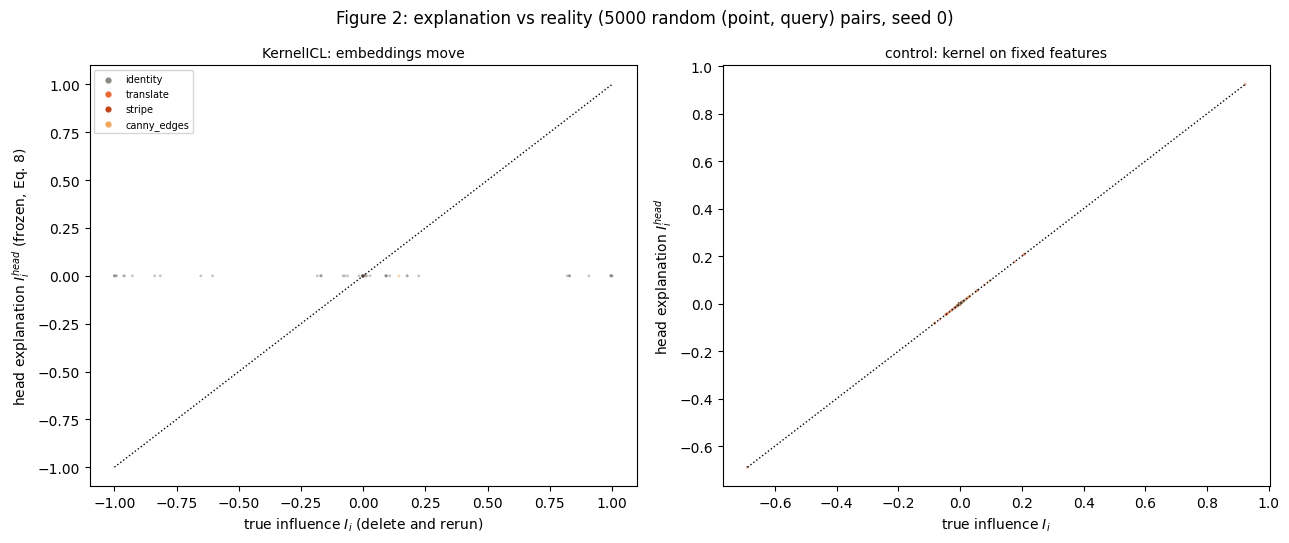

In [30]:
d = SEED_DATA[SEEDS[0]]
rng = np.random.default_rng(0)
n, m = d["I"].shape
pairs = rng.choice(n * m, size=min(SCATTER_PAIRS, n * m), replace=False)
points = pairs // m
colours = [GROUP_COLOURS[k] for k in d["main"]["g"][points]]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
scatter_with_diagonal(axes[0], d["I"].ravel()[pairs], d["I_head"].ravel()[pairs], colours,
                      "KernelICL: embeddings move", "true influence $I_i$ (delete and rerun)",
                      "head explanation $I^{head}_i$ (frozen, Eq. 8)")
legend_for_groups(axes[0], d["main"]["g"])
n_a = len(d["audit_rows"])
pairs_ff = rng.choice(n_a * m, size=min(SCATTER_PAIRS, n_a * m), replace=False)
colours_ff = [GROUP_COLOURS[k] for k in d["main"]["g"][d["audit_rows"]][pairs_ff // m]]
scatter_with_diagonal(axes[1], d["I_ff"].ravel()[pairs_ff], d["I_head_ff"].ravel()[pairs_ff], colours_ff,
                      "control: kernel on fixed features", "true influence $I_i$", "head explanation $I^{head}_i$")
fig.suptitle(f"Figure 2: explanation vs reality ({len(pairs)} random (point, query) pairs, seed {d['seed']})")
plt.tight_layout()
plt.show()

**How to read this:** each dot is one (deleted point, query) pair, coloured by the deleted point's group. On the dotted line the frozen explanation predicts the deletion exactly. The right panel is the control: with fixed features every dot must lie on the line. In the left panel, the distance from the line is what the representation change adds, the effect the paper's Figure 1(c) draws but could not measure.

## 3.2 By group

The same metrics, split by the deleted point's group (rare / clean) and the query's group. Below, pairs where the deleted point and the query share the digit, or share the corruption.

In [31]:
rows = []
for seed in SEEDS:
    d = SEED_DATA[seed]
    rows += group_rows(d["I"], d["I_head"], is_rare(d["main"]["g"]), is_rare(d["queries"]["g"]), seed=seed)
GROUPS_3 = mean_and_se(pd.DataFrame(rows), ["edited", "query"], METRICS)
display(mean_se_table(GROUPS_3, ["edited", "query"], METRICS))

,edited,query,bias,rms,rms_actual,relative_rms,sign_agreement,top_k_overlap,n_seeds
0,clean,all,0.000 ± 0.000,0.045 ± 0.003,0.045 ± 0.003,0.995 ± 0.001,0.513 ± 0.029,0.584 ± 0.004,10
1,clean,clean,0.000 ± 0.000,0.017 ± 0.005,0.017 ± 0.005,0.959 ± 0.018,0.495 ± 0.124,0.263 ± 0.009,10
2,clean,rare,0.000 ± 0.000,0.049 ± 0.004,0.050 ± 0.004,0.994 ± 0.001,0.499 ± 0.033,0.691 ± 0.004,10
3,rare,all,0.001 ± 0.000,0.072 ± 0.002,0.076 ± 0.002,0.955 ± 0.004,0.496 ± 0.021,0.695 ± 0.002,10
4,rare,clean,0.000 ± 0.000,0.026 ± 0.005,0.028 ± 0.005,0.898 ± 0.035,0.523 ± 0.114,0.446 ± 0.007,10
5,rare,rare,0.001 ± 0.000,0.081 ± 0.003,0.085 ± 0.002,0.954 ± 0.005,0.488 ± 0.020,0.778 ± 0.002,10


In [32]:
rows = []
for seed in SEEDS:
    d = SEED_DATA[seed]
    E = d["I"] - d["I_head"]
    same_digit = d["y_enc"][:, None] == d["yq_enc"][None, :]
    same_group = d["main"]["g"][:, None] == d["queries"]["g"][None, :]
    for name, mask in [("same digit", same_digit), ("different digit", ~same_digit),
                       ("same corruption (rare only)", same_group & is_rare(d["main"]["g"])[:, None]),
                       ("different group", ~same_group)]:
        rows.append({"seed": seed, "pairs": name, "rms": float(np.sqrt(np.mean(E[mask] ** 2))),
                     "rms_actual": float(np.sqrt(np.mean(d["I"][mask] ** 2)))})
PAIRS_3 = pd.DataFrame(rows)
PAIRS_3["relative_rms"] = PAIRS_3["rms"] / PAIRS_3["rms_actual"]
display(mean_se_table(mean_and_se(PAIRS_3, ["pairs"], ["rms", "rms_actual", "relative_rms"]), ["pairs"],
                      ["rms", "rms_actual", "relative_rms"]))

,pairs,rms,rms_actual,relative_rms,n_seeds
0,different digit,0.045 ± 0.003,0.046 ± 0.003,0.994 ± 0.001,10
1,different group,0.050 ± 0.004,0.050 ± 0.004,0.991 ± 0.001,10
2,same corruption (rare only),0.104 ± 0.002,0.110 ± 0.002,0.946 ± 0.006,10
3,same digit,0.058 ± 0.002,0.060 ± 0.002,0.961 ± 0.004,10


**How to read this:** compare `relative_rms` for `edited = rare` with `edited = clean`: does the frozen explanation miss more when a rare point is deleted? The query split shows whether the error lands on rare or clean queries. The pair table shows whether errors concentrate where the deleted point and the query share a digit or a corruption.

## 3.3 Where the error comes from (figure 5)

Rank correlations: is the error larger for pairs where the deleted point carried more kernel weight $w_i(x)$, and for points that are hard to predict (refit $L_i^{\mathrm{rec}}$)?

In [33]:
rows = []
for seed in SEEDS:
    d = SEED_DATA[seed]
    abs_E = np.abs(d["I"] - d["I_head"])
    rows.append({"seed": seed,
                 "spearman |E| vs weight w_i(x)": spearmanr(abs_E.ravel(), d["W"].T.ravel())[0],
                 "spearman point RMS(E) vs refit L_i": spearmanr(np.sqrt(np.mean(abs_E ** 2, axis=1)), d["L_refit"])[0]})
CORR_3 = pd.DataFrame(rows)
CORR_3["all"] = "all seeds"
cols = ["spearman |E| vs weight w_i(x)", "spearman point RMS(E) vs refit L_i"]
display(mean_se_table(mean_and_se(CORR_3, ["all"], cols), ["all"], cols))

,all,spearman |E| vs weight w_i(x),spearman point RMS(E) vs refit L_i,n_seeds
0,all seeds,0.094 ± 0.002,0.083 ± 0.008,10


**How to read this:** a positive first correlation means the explanation errs most where it also says the point matters most; a positive second one means it errs most for points the model finds hard without them.

**Figure 5** shows one worked example: the rare context point whose deletion the frozen explanation gets most wrong. KernelICL embeddings of context and queries are drawn in 2-D before and after deleting it, with arrows for the movement. PCA is fitted once on the full-context embeddings and both states are projected into the same coordinates (UMAP would distort the arrows). Next to it: the deleted image and the 5 queries whose prediction changed most.

In [34]:
d = SEED_DATA[SEEDS[0]]
rare_pos = np.where(is_rare(d["main"]["g"]))[0]
i_star = rare_pos[np.argmax(np.sqrt(np.mean((d["I"] - d["I_head"])[rare_pos] ** 2, axis=1)))]
after = {}
run_edits(d["pred"], lambda j: deleted(d, i_star, d["q_rows"]), 1,
          lambda j, probs, E_train, E_test: after.update(H_ctx=project(d["pred"], E_train), H_q=project(d["pred"], E_test)),
          return_embeddings=True)
keep = np.arange(len(d["y_enc"])) != i_star
pca = PCA(2).fit(np.vstack([d["H_ctx"], d["H_q"]]))
before_ctx, before_q = pca.transform(d["H_ctx"][keep]), pca.transform(d["H_q"])
after_ctx, after_q = pca.transform(after["H_ctx"]), pca.transform(after["H_q"])
rng = np.random.default_rng(0)
show_ctx = rng.choice(len(before_ctx), size=min(60, len(before_ctx)), replace=False)
show_q = np.argsort(-np.abs(d["I"][i_star]))[:5]

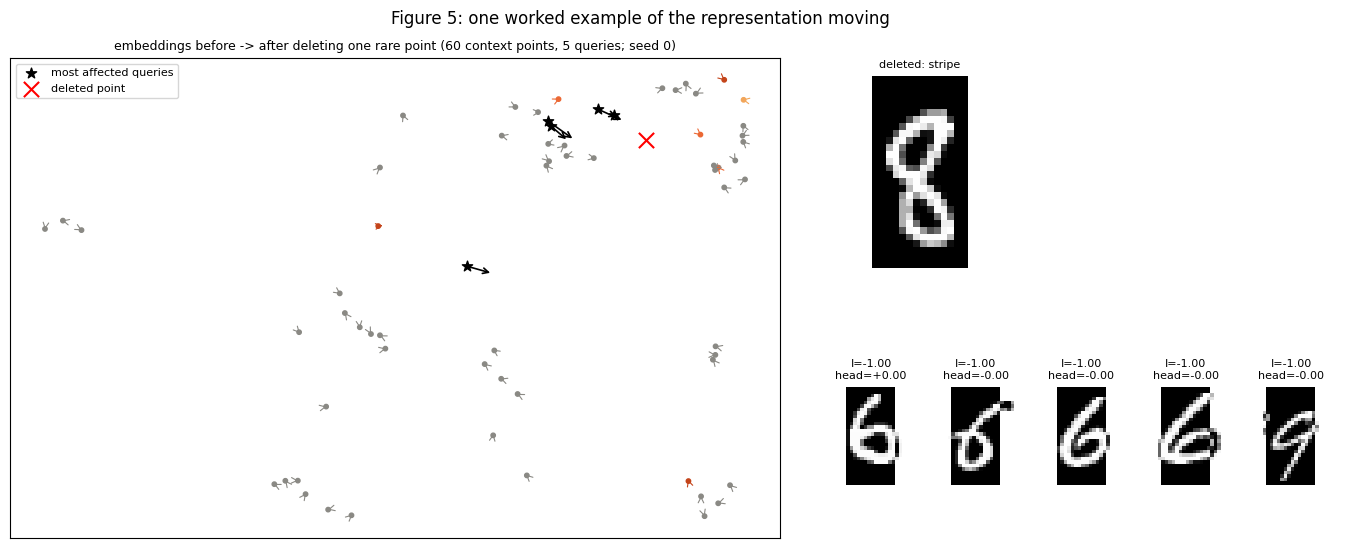

In [35]:
fig = plt.figure(figsize=(14, 6))
ax = fig.add_axes([0.05, 0.1, 0.55, 0.8])
g_ctx = d["main"]["g"][keep]
for j in show_ctx:
    ax.annotate("", xy=after_ctx[j], xytext=before_ctx[j], arrowprops=dict(arrowstyle="->", color=GROUP_COLOURS[g_ctx[j]], lw=0.8))
for j in show_q:
    ax.annotate("", xy=after_q[j], xytext=before_q[j], arrowprops=dict(arrowstyle="->", color="k", lw=1.2))
ax.scatter(before_ctx[show_ctx, 0], before_ctx[show_ctx, 1], c=[GROUP_COLOURS[k] for k in g_ctx[show_ctx]], s=10)
ax.scatter(before_q[show_q, 0], before_q[show_q, 1], marker="*", c="k", s=60, label="most affected queries")
deleted_xy = pca.transform(d["H_ctx"][i_star:i_star + 1])[0]
ax.scatter(*deleted_xy, marker="x", c="red", s=120, label="deleted point")
ax.legend(fontsize=8)
ax.set_title(f"embeddings before -> after deleting one rare point (60 context points, 5 queries; seed {d['seed']})", fontsize=9)
ax.set_xticks([]); ax.set_yticks([])
ax_img = fig.add_axes([0.63, 0.55, 0.14, 0.32])
show_image(ax_img, d["main"], i_star, f"deleted: {GROUP_NAMES[d['main']['g'][i_star]]}")
for r, j in enumerate(show_q):
    ax_q = fig.add_axes([0.63 + 0.075 * r, 0.12, 0.07, 0.3])
    show_image(ax_q, d["queries"], j, f"I={d['I'][i_star, j]:+.2f}\nhead={d['I_head'][i_star, j]:+.2f}", split="test")
fig.suptitle("Figure 5: one worked example of the representation moving")
plt.show()

**How to read this:** arrows show how each embedding moves when the red-crossed point is deleted (coloured: context points by group; black: the 5 most affected queries). The frozen explanation assumes no arrow moves. Under each query image, `I` is the true change in the audited probability and `head` what the frozen explanation predicted.

## 3.4 Context length (figure 4)

Does the frozen explanation get better or worse as the context grows (paper §7, open question)? Nested contexts of `SWEEP_SIZES` rows (each smaller one a random subset of the next, stratified by group). On each, the audit set (all rare points + `N_AUDIT_COMMON` clean points of that context) is deleted one at a time. γ stays the seed's γ; each context gets its own TabICL preprocessing, matched within it. **n = 2 × `N_CTX` is beyond the checkpoint's fine-tuning range (≤ 1,024 rows)** and is marked as such. The main size reuses Section 3.1.

In [36]:
def sweep_audit(d, n, rng):
    """Deletion audit rows (rare / clean deleted points) on the nested context of size n."""
    pos = d["positions"][n]
    s, X = take(d["superset"], pos), d["X_super"][pos]
    pred = KernelICLPredictor(MODEL, X, s["y"], gamma=d["gamma"])
    if pred.n_classes_ != d["pred"].n_classes_:
        return None  # a class is missing from this small context: label encodings would not line up
    y_enc = pred.clf.y_encoder_.transform(s["y"])
    P, _ = pred.predict_proba_and_weights(d["X_q"])
    E_train, E_q = _embed(pred.clf, d["X_q"])
    log_K = -d["gamma"] * squared_distances(project(pred, E_q), project(pred, E_train))
    ctx_rows, q_rows, labels = pred.processed(d["X_q"])
    rare = is_rare(s["g"])
    common = rng.choice(np.where(~rare)[0], size=min(N_AUDIT_COMMON, int((~rare).sum())), replace=False)
    rows_audit = np.sort(np.concatenate([np.where(rare)[0], common]))
    I = np.zeros((len(rows_audit), len(d["yq_enc"])))
    view = {"ctx_rows": ctx_rows, "labels": labels}

    def handle(r, probs):
        I[r] = coordinate(P, d["out_cls"]) - coordinate(probs, d["out_cls"])

    run_edits(pred, lambda r: deleted(view, rows_audit[r], q_rows), len(rows_audit), handle)
    I_head = frozen_deletion_head(P, log_K, y_enc, d["out_cls"], pred.n_classes_, rows=rows_audit)
    return I, I_head, rare[rows_audit]

In [37]:
t0 = time.time()
rows = []
for seed in SEEDS:
    d = SEED_DATA[seed]
    rng = np.random.default_rng([seed, 34])
    for n in SWEEP_SIZES:
        if n == N_CTX:
            I, I_head, point_rare = d["I"][d["audit_rows"]], d["I_head"][d["audit_rows"]], is_rare(d["main"]["g"][d["audit_rows"]])
        else:
            result = sweep_audit(d, n, rng)
            if result is None:
                RUN_LOG.append(f"seed {seed}: sweep context n = {n} lacks a class; skipped")
                continue
            I, I_head, point_rare = result
        for r in fig3_rows(seed, "deletion", I, I_head, point_rare):
            rows.append({**r, "n": len(d["positions"][n])})
    print(f"seed {seed} done ({time.time() - t0:.0f}s)")
SWEEP_3 = mean_and_se(pd.DataFrame(rows), ["n", "points"], ["relative_rms"])
display(mean_se_table(SWEEP_3, ["n", "points"], ["relative_rms"]))

seed 0 done (15s)
seed 1 done (29s)
seed 2 done (44s)
seed 3 done (59s)
seed 4 done (73s)
seed 5 done (88s)
seed 6 done (103s)
seed 7 done (117s)
seed 8 done (132s)
seed 9 done (147s)


,n,points,relative_rms,n_seeds
0,250,clean,0.995 ± 0.001,10
1,250,rare,0.956 ± 0.008,10
2,500,clean,0.996 ± 0.002,10
3,500,rare,0.953 ± 0.002,10
4,1000,clean,0.994 ± 0.002,10
5,1000,rare,0.955 ± 0.004,10
6,2000,clean,0.998 ± 0.001,10
7,2000,rare,0.957 ± 0.003,10


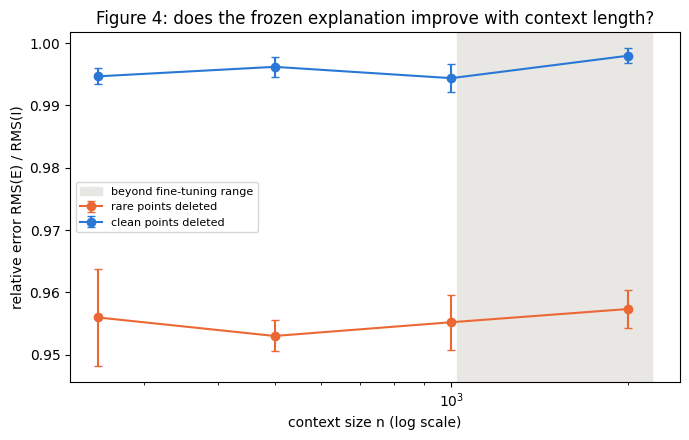

In [38]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for name, colour in [("rare", "#eb6834"), ("clean", "#2a78d6")]:
    rows = SWEEP_3[SWEEP_3.points == name].sort_values("n")
    ax.errorbar(rows["n"], rows["relative_rms_mean"], yerr=rows["relative_rms_se"], marker="o", capsize=3,
                color=colour, label=f"{name} points deleted")
if SWEEP_3["n"].max() > 1024:
    ax.axvspan(1024, SWEEP_3["n"].max() * 1.1, color="#e8e7e3", label="beyond fine-tuning range")
ax.set_xscale("log")
ax.set_xlabel("context size n (log scale)")
ax.set_ylabel("relative error RMS(E) / RMS(I)")
ax.legend(fontsize=8)
ax.set_title("Figure 4: does the frozen explanation improve with context length?")
plt.tight_layout()
plt.show()

**How to read this:** each point is the mean relative error over seeds (±1 SE) at one context size, for deleting rare and clean points. A falling line means the head explanation becomes more faithful in larger contexts (each point matters less to the representation); a rising one means it becomes less faithful. The grey band marks sizes beyond the checkpoint's fine-tuning range.

# 4. Label replacement and admission audits

Two more context edits from paper App. B.6. Sign convention: these effects are **after minus before** (paper App. C.3/C.4), unlike deletion's $I_i = f_{\mathcal D} - f_{\mathcal D^{-i}}$. In every case the error is the recomputed effect minus the frozen effect.

## 4.1 Label replacement (App. C.3)

For every point of the audit set, replace its label by a random other digit (seeded) and keep everything else. Frozen effect: $w_i(x)\,([v = c] - [y_i = c])$ for the audited class c. Covariates and context size are unchanged, but label-conditioned embeddings can still move (App. B.4).

In [39]:
def relabel_audit(d, rng):
    """(actual, frozen, rare mask) for label replacement on the audit set."""
    rows = d["audit_rows"]
    y_new = (d["y_enc"][rows] + rng.integers(1, d["pred"].n_classes_, len(rows))) % d["pred"].n_classes_
    actual = np.zeros((len(rows), len(d["yq_enc"])))

    def make(r):
        labels = d["labels"].clone()
        labels[rows[r]] = float(y_new[r])
        return {"rows": d["ctx_rows"], "labels": labels, "queries": d["q_rows"]}

    def handle(r, probs):
        actual[r] = coordinate(probs, d["out_cls"]) - coordinate(d["P"], d["out_cls"])

    run_edits(d["pred"], make, len(rows), handle)
    frozen = frozen_relabel_effects(d["W"], d["y_enc"][rows], y_new, d["out_cls"], rows)
    return actual, frozen, is_rare(d["main"]["g"][rows])


t0 = time.time()
rows_41 = []
FIG3 = keep_other_edits(FIG3, "label replacement")
for seed in SEEDS:
    d = SEED_DATA[seed]
    actual, frozen, point_rare = relabel_audit(d, np.random.default_rng([seed, 41]))
    rows_41 += group_rows(actual, frozen, point_rare, is_rare(d["queries"]["g"]), seed=seed)
    FIG3 += fig3_rows(seed, "label replacement", actual, frozen, point_rare)
    print(f"seed {seed} done ({time.time() - t0:.0f}s)")
RELABEL_4 = mean_and_se(pd.DataFrame(rows_41), ["edited", "query"], METRICS)
display(mean_se_table(RELABEL_4[RELABEL_4["query"] == "all"], ["edited"], METRICS))

seed 0 done (4s)
seed 1 done (8s)
seed 2 done (12s)
seed 3 done (16s)
seed 4 done (20s)
seed 5 done (25s)
seed 6 done (29s)
seed 7 done (33s)
seed 8 done (37s)
seed 9 done (41s)


,edited,bias,rms,rms_actual,relative_rms,sign_agreement,top_k_overlap,n_seeds
0,clean,-0.002 ± 0.001,0.111 ± 0.002,0.110 ± 0.002,1.017 ± 0.003,0.016 ± 0.002,0.631 ± 0.004,10
1,rare,-0.000 ± 0.001,0.128 ± 0.002,0.123 ± 0.002,1.037 ± 0.006,0.179 ± 0.007,0.638 ± 0.004,10


**How to read this:** the same metrics as Section 3, for relabelling a rare or a clean point (all queries). Compare `relative_rms` with deletion's: label replacement keeps the covariates, so any extra error comes only from the label entering the embeddings.

## 4.2 Admission (paper §4.3, Eq. 11–12)

Append one candidate z (an image not in the context) with label v. Frozen effect: $a_z(x)\,[v - f(x)]$ with $a_z(x) = k(x,z) / (Z_{\mathcal D}(x) + k(x,z))$, using z's label-free query embedding in the original context. Recomputed: rerun with z appended. The remainder $\rho_z$ is the representation response to admitting a row.

Two labels per candidate, recorded separately as the paper requires: the **observed** (true) label and a **pseudo-label** (KernelICL's own prediction for z). No admission policy is evaluated.

In [40]:
def admission_audit(d, v):
    """(actual, frozen) admission effects for every candidate with labels v (encoded)."""
    n_cand = len(v)
    actual = np.zeros((n_cand, len(d["yq_enc"])))

    def make(c):
        return {"rows": torch.cat([d["ctx_rows"], d["c_rows"][c:c + 1]]),
                "labels": torch.cat([d["labels"], d["labels"].new_tensor([float(v[c])])]),
                "queries": d["q_rows"]}

    def handle(c, probs):
        actual[c] = coordinate(probs, d["out_cls"]) - coordinate(d["P"], d["out_cls"])

    run_edits(d["pred"], make, n_cand, handle)
    log_K_q = -d["gamma"] * squared_distances(d["H_q"], d["H_ctx"])
    log_k_z = -d["gamma"] * squared_distances(d["H_c"], d["H_q"])
    frozen = frozen_admission_effects(log_k_z, logsumexp(log_K_q, axis=1), d["P"], v, d["out_cls"])
    return actual, frozen

In [41]:
t0 = time.time()
rows_42 = []
FIG3 = keep_other_edits(FIG3, "admission")
for seed in SEEDS:
    d = SEED_DATA[seed]
    observed = d["pred"].clf.y_encoder_.transform(d["candidates"]["y"])
    log_K_c = -d["gamma"] * squared_distances(d["H_c"], d["H_ctx"])
    pseudo = kernel_head_proba(log_K_c, d["y_enc"], d["pred"].n_classes_)[0].argmax(axis=1)
    cand_rare = is_rare(d["candidates"]["g"])
    for label_name, v in [("observed", observed), ("pseudo-label", pseudo)]:
        actual, frozen = admission_audit(d, v)
        splits = [("all", np.ones(len(v), dtype=bool))]
        if label_name == "pseudo-label":
            splits += [("pseudo correct", pseudo == observed), ("pseudo wrong", pseudo != observed)]
        for split_name, mask in splits:
            for group_name, gmask in [("rare", cand_rare), ("clean", ~cand_rare)]:
                if (mask & gmask).any():
                    rows_42.append(audit_row(actual[mask & gmask], frozen[mask & gmask], seed=seed, label=label_name,
                                             candidates=split_name, group=group_name))
        FIG3 += fig3_rows(seed, f"admission ({label_name})", actual, frozen, cand_rare)
    print(f"seed {seed}: pseudo-label accuracy {np.mean(pseudo == observed):.2f} ({time.time() - t0:.0f}s)")
ADMIT_4 = mean_and_se(pd.DataFrame(rows_42), ["label", "candidates", "group"], METRICS)
display(mean_se_table(ADMIT_4, ["label", "candidates", "group"], METRICS))

seed 0: pseudo-label accuracy 0.76 (6s)
seed 1: pseudo-label accuracy 0.75 (11s)
seed 2: pseudo-label accuracy 0.93 (17s)
seed 3: pseudo-label accuracy 0.70 (23s)
seed 4: pseudo-label accuracy 0.81 (28s)
seed 5: pseudo-label accuracy 0.79 (34s)
seed 6: pseudo-label accuracy 0.86 (39s)
seed 7: pseudo-label accuracy 0.81 (45s)
seed 8: pseudo-label accuracy 0.78 (51s)
seed 9: pseudo-label accuracy 0.76 (56s)


,label,candidates,group,bias,rms,rms_actual,relative_rms,sign_agreement,top_k_overlap,n_seeds
0,observed,all,clean,-0.000 ± 0.000,0.046 ± 0.003,0.046 ± 0.003,1.016 ± 0.012,0.032 ± 0.006,0.871 ± 0.002,10
1,observed,all,rare,0.002 ± 0.000,0.087 ± 0.004,0.071 ± 0.003,1.215 ± 0.022,0.300 ± 0.012,0.604 ± 0.009,10
2,pseudo-label,all,clean,-0.000 ± 0.000,0.046 ± 0.004,0.045 ± 0.004,1.016 ± 0.013,0.027 ± 0.006,0.871 ± 0.003,10
3,pseudo-label,all,rare,0.001 ± 0.000,0.079 ± 0.003,0.066 ± 0.002,1.210 ± 0.022,0.256 ± 0.008,0.615 ± 0.009,10
4,pseudo-label,pseudo correct,clean,-0.000 ± 0.000,0.045 ± 0.004,0.045 ± 0.004,1.008 ± 0.011,0.026 ± 0.006,0.875 ± 0.003,10
5,pseudo-label,pseudo correct,rare,0.000 ± 0.000,0.072 ± 0.003,0.062 ± 0.002,1.155 ± 0.027,0.210 ± 0.009,0.701 ± 0.011,10
6,pseudo-label,pseudo wrong,clean,-0.001 ± 0.001,0.048 ± 0.008,0.045 ± 0.010,1.103 ± 0.103,0.042 ± 0.042,nan ± nan,3
7,pseudo-label,pseudo wrong,rare,0.002 ± 0.001,0.097 ± 0.003,0.075 ± 0.002,1.305 ± 0.028,0.364 ± 0.012,0.862 ± 0.013,10


**How to read this:** each row is a set of admitted candidates (rare / clean; for pseudo-labels also split by whether the pseudo-label was right). `rms` is the typical remainder $\rho_z$, the part of the admission effect that the frozen formula misses; `relative_rms` scales it by the effect itself. A larger remainder for wrong pseudo-labels would mean the frozen formula is least reliable exactly when a pseudo-label is harmful. A small remainder says the formula explains the admission, not that admitting is a good idea.

# 5. Reweighting audit (Eq. 13 vs Eq. D.7)

Upweighting points can be done in the head (Eq. 13: multiply their votes, embeddings frozen) or by **resampling** the context and rerunning (what a TFM without a kernel head allows). With KernelICL both are available, so the gap splits exactly (paper Eq. D.7):

$$f_{\mathcal D^{(c)}} - f^{\mathrm{fr}}_{m|\mathcal D} = \underbrace{[f_{\mathcal D^{(c)}} - f^{\mathrm{fr}}_{c|\mathcal D}]}_{\text{recomputation}} + \underbrace{[f^{\mathrm{fr}}_{c|\mathcal D} - f^{\mathrm{fr}}_{m|\mathcal D}]}_{\text{sampling}}$$

where m are the multipliers and c the realised counts of one resampled context. Conditions: uniform resampling (m = 1), the pre-registered tail (τ = 0.95, λ = 8 on the refit score $L^{\mathrm{rec}}$) and its random-tail control (same size), `N_DRAWS` draws each. The existing notebook's Table D could only approximate this split.

In [42]:
def reweighting_audit(d, m, rng):
    """Per draw: recomputed, frozen-with-counts and frozen-with-multipliers audited probabilities."""
    n = len(d["y_enc"])
    log_K_q = -d["gamma"] * squared_distances(d["H_q"], d["H_ctx"])
    f_m = coordinate(kernel_head_proba(log_K_q, d["y_enc"], d["pred"].n_classes_, m=m)[0], d["out_cls"])
    draws = []
    for _ in range(N_DRAWS):
        _, _, idx = resample_context(np.arange(n)[:, None], d["y_enc"], m, target_unique=None, max_mult=None,
                                     rng=rng, return_indices=True)
        idx_t = torch.as_tensor(idx, device=d["labels"].device)
        result = {}
        run_edits(d["pred"], lambda j: {"rows": d["ctx_rows"][idx_t], "labels": d["labels"][idx_t], "queries": d["q_rows"]},
                  1, lambda j, probs: result.update(rec=coordinate(probs, d["out_cls"])))
        counts = np.bincount(idx, minlength=n).astype(float)
        f_c = coordinate(kernel_head_proba(log_K_q, d["y_enc"], d["pred"].n_classes_, m=counts)[0], d["out_cls"])
        draws.append((result["rec"], f_c, f_m))
    return draws

In [43]:
t0 = time.time()
rows_5 = []
FIG3 = keep_other_edits(FIG3, "reweighting")
for seed in SEEDS:
    d = SEED_DATA[seed]
    rng = np.random.default_rng([seed, 5])
    n = len(d["y_enc"])
    m_tail = tail_multiplier(d["L_refit"], LAM, TAU)
    conditions = {"uniform resampling": np.ones(n), "tail (refit score)": m_tail,
                  "random tail": random_tail_multiplier(n, int(np.sum(m_tail > 1)), LAM, rng)}
    f_D = coordinate(d["P"], d["out_cls"])
    q_rare = is_rare(d["queries"]["g"])
    for name, m in conditions.items():
        for draw, (f_rec, f_c, f_m) in enumerate(reweighting_audit(d, m, rng)):
            for query_name, mask in [("all", np.ones_like(q_rare)), ("rare", q_rare), ("clean", ~q_rare)]:
                total, recomputation = rms_masked(f_rec - f_D, mask), rms_masked(f_rec - f_c, mask)
                rows_5.append({"seed": seed, "condition": name, "draw": draw, "queries": query_name,
                               "rms_total_change": total, "rms_recomputation": recomputation,
                               "rms_sampling": rms_masked(f_c - f_m, mask),
                               "relative_recomputation": recomputation / max(total, 1e-12)})
                if name == "tail (refit score)" and query_name != "all":
                    FIG3.append({"seed": seed, "edit": "reweighting (recomputation term)", "points": query_name,
                                 "relative_rms": recomputation / max(total, 1e-12)})
    print(f"seed {seed} done ({time.time() - t0:.0f}s)")
cols = ["rms_total_change", "rms_recomputation", "rms_sampling", "relative_recomputation"]
REWEIGHT_5 = mean_and_se(pd.DataFrame(rows_5).groupby(["seed", "condition", "queries"], as_index=False)[cols].mean(),
                         ["condition", "queries"], cols)
display(mean_se_table(REWEIGHT_5, ["condition", "queries"], cols))

seed 0 done (1s)
seed 1 done (2s)
seed 2 done (2s)
seed 3 done (3s)
seed 4 done (4s)
seed 5 done (5s)
seed 6 done (6s)
seed 7 done (6s)
seed 8 done (7s)
seed 9 done (8s)


,condition,queries,rms_total_change,rms_recomputation,rms_sampling,relative_recomputation,n_seeds
0,random tail,all,0.304 ± 0.003,0.290 ± 0.003,0.173 ± 0.005,0.953 ± 0.007,10
1,random tail,clean,0.114 ± 0.005,0.112 ± 0.005,0.047 ± 0.009,0.987 ± 0.031,10
2,random tail,rare,0.345 ± 0.003,0.328 ± 0.004,0.196 ± 0.006,0.952 ± 0.007,10
3,tail (refit score),all,0.279 ± 0.003,0.281 ± 0.003,0.071 ± 0.005,1.006 ± 0.003,10
4,tail (refit score),clean,0.108 ± 0.008,0.108 ± 0.008,0.024 ± 0.009,0.996 ± 0.018,10
5,tail (refit score),rare,0.316 ± 0.004,0.318 ± 0.004,0.078 ± 0.006,1.006 ± 0.003,10
6,uniform resampling,all,0.281 ± 0.003,0.265 ± 0.004,0.153 ± 0.004,0.942 ± 0.006,10
7,uniform resampling,clean,0.107 ± 0.007,0.103 ± 0.007,0.036 ± 0.009,0.944 ± 0.042,10
8,uniform resampling,rare,0.318 ± 0.003,0.299 ± 0.004,0.174 ± 0.005,0.941 ± 0.006,10


**How to read this:** per condition and query group (draws averaged, then mean ± SE over seeds). `rms_total_change` is how much resampling moves the audited probability from the full-context prediction; `rms_recomputation` is the part due to the representation being recomputed on the resampled context; `rms_sampling` is the part due to drawing counts instead of applying the exact multipliers. `relative_recomputation` near 0 means head reweighting is a good model of resampling; near 1 means the representation response dominates. For figure 3 the rows are split by query group (rare / clean), since no single point is edited.

# 6. GP head on KernelICL embeddings (paper App. A.6)

The paper's reference GP head on the frozen KernelICL embeddings: GP **regression** on one-hot labels with a Gaussian covariance. Regression, not a GP classifier, because its leave-one-out and frozen-deletion formulas are exact; a classifier would need an approximation whose error would mix into the audit (paper §6 / Eq. E.6). Outputs are not calibrated probabilities: accuracy uses the argmax, the audit the audited coordinate.

γ_GP and σ² were chosen per seed in 0.8 by held-out log-likelihood on the re-embedded folds (not GP leave-one-out on the context embeddings, which contain their own labels; App. A.6 caveat). Backbone and W are untouched. The recomputed GP predictions come from the deletion passes of 2.2 (same γ_GP, σ²; refitting them would add a third term, Eq. 14 / E.6, not run).

## 6.1 Prediction

In [44]:
rows = []
for seed in SEEDS:
    d = SEED_DATA[seed]
    for name, scores in [("kernel vote", d["P"]), ("GP head", d["gp_mu"])]:
        rows.append({"seed": seed, "head": name, **group_accuracy_metrics(scores.argmax(axis=1), d["yq_enc"], d["queries"]["g"],
                                                                         N_GROUPS, d["rho"], rare_groups=RARE_GROUPS)})
GP_ACC_6 = mean_and_se(pd.DataFrame(rows), ["head"], ["worst_group", "balanced_mean"] + [f"acc_g{k}" for k in range(N_GROUPS)])
display(mean_se_table(GP_ACC_6, ["head"], ["worst_group", "balanced_mean"] + [f"acc_g{k}" for k in range(N_GROUPS)])
        .rename(columns={f"acc_g{k}": GROUP_NAMES[k] for k in range(N_GROUPS)}))

,head,worst_group,balanced_mean,identity,translate,stripe,canny_edges,n_seeds
0,GP head,0.547 ± 0.008,0.818 ± 0.004,0.981 ± 0.003,0.547 ± 0.008,0.889 ± 0.007,0.855 ± 0.013,10
1,kernel vote,0.538 ± 0.009,0.814 ± 0.005,0.981 ± 0.002,0.538 ± 0.009,0.881 ± 0.009,0.854 ± 0.012,10


**How to read this:** test accuracy per group of the two heads on the same KernelICL embeddings. The GP head can weight neighbours negatively and does not normalise its weights, so it is a different predictor, not a variant of the vote.

## 6.2 GP deletion audit

In [45]:
rows = []
FIG3 = keep_other_edits(FIG3, "GP-head")
for seed in SEEDS:
    d = SEED_DATA[seed]
    actual = coordinate(d["gp_mu"], d["out_cls"])[None, :] - d["rec"]["gp_coord"]
    frozen = gp_frozen_deletion_effects(d["gp_K_q"], d["gp_Q"], d["gp_alpha"], d["out_cls"])
    point_rare = is_rare(d["main"]["g"])
    rows += group_rows(actual, frozen, point_rare, is_rare(d["queries"]["g"]), seed=seed)
    FIG3 += fig3_rows(seed, "GP-head deletion", actual, frozen, point_rare)
GP_AUDIT_6 = mean_and_se(pd.DataFrame(rows), ["edited", "query"], METRICS)
display(mean_se_table(GP_AUDIT_6[GP_AUDIT_6["query"] == "all"], ["edited"], METRICS))

,edited,bias,rms,rms_actual,relative_rms,sign_agreement,top_k_overlap,n_seeds
0,clean,0.000 ± 0.000,0.004 ± 0.000,0.004 ± 0.000,0.955 ± 0.004,0.516 ± 0.001,0.320 ± 0.007,10
1,rare,0.001 ± 0.000,0.016 ± 0.000,0.017 ± 0.000,0.916 ± 0.007,0.546 ± 0.002,0.435 ± 0.006,10


**How to read this:** the deletion audit of Section 3 for the GP head: the frozen-covariance deletion formula (exact for fixed embeddings) against the GP refitted on the recomputed embeddings. Compare `relative_rms` with the kernel vote's in 3.2: a smaller value means the GP head's explanation survives representation changes better.

# 7. Sanity-check summary

Checks 1, 2, 3, 4 and 6 stop the notebook if they fail. Check 5 records a noise floor instead, and check 7 only warns.

In [46]:
for name in ["1", "2", "3", "4", "5", "6", "7"]:
    found = [k for k in SANITY if k.startswith(name + " ")]
    print(f"{found[0] if found else name:45s} {SANITY[found[0]] if found else 'not run (its section was skipped)'}")
print("\nRun notes:" if RUN_LOG else "\nRun notes: none")
for note in RUN_LOG:
    print(" -", note)

1 labels identical across folders             pass
2 exact context composition                   pass (asserted for every set)
3 checkpoint limits                           pass (<= 10 classes, 64 features, 1000 rows; sweep point 2000 rows labelled)
4 formula checks                              pass
5 determinism and row-order invariance        WARNING: noise floor 3.1e-05 (see 0.7)
6 fixed-feature control E = 0                 pass (max |E| = 1.0e-12)
7 baseline gap                                pass

Run notes:
 - seed 0: gamma = 10.0 is at the edge of GAMMA_GRID
 - seed 1: gamma = 10.0 is at the edge of GAMMA_GRID
 - seed 2: gamma = 10.0 is at the edge of GAMMA_GRID
 - seed 3: gamma = 10.0 is at the edge of GAMMA_GRID
 - seed 4: gamma = 10.0 is at the edge of GAMMA_GRID
 - seed 5: gamma = 10.0 is at the edge of GAMMA_GRID
 - seed 6: gamma = 10.0 is at the edge of GAMMA_GRID
 - seed 7: gamma = 10.0 is at the edge of GAMMA_GRID
 - seed 8: gamma = 10.0 is at the edge of GAMMA_GRID
 - 

# 8. Decisions

Declared defaults (spec §6), and implementation choices made while building:

**Model and calibration**
* KernelICL `paper.pt` as released: no fine-tuning on MNIST-C (option (a)). One forward pass, no ensembling or shuffling.
* γ by the KernelICL paper's protocol (`kernelicl_clinical.fold_embeddings` + `calibrate_scale`: 5 stratified folds, each re-embedded with label-free validation queries; the sparsest γ within 0.01 of the best accuracy), fixed for every edit of the seed and for every sweep context. Not frozen-LOO likelihood, which uses label-leaking context embeddings.
* GP head (option (c)): regression on one-hot labels on the 512-d projected embeddings; γ_GP and σ² ∈ {0.01, 0.1, 1} by held-out log-likelihood on the same folds; fixed during deletions. **Deviation from the spec:** γ_GP is searched over 13 values from 0.1 to 1000 times 1 / (median squared distance between the embeddings), not over `GAMMA_GRID`, because in the smoke test `GAMMA_GRID` put γ_GP at its lower edge (the embeddings' scale differs from the kernel head's). Edge hits of either γ search are logged in Section 7.
* Fixed-feature control: Gaussian kernel on the 64 input features, γ by frozen-LOO likelihood (honest on label-free features), brute-forced on the audit set (~110 points per seed) rather than all points: it is a correctness check, and this keeps it fast.
* Speed (no effect on results): the GP refits of 2.2 run in torch on the GPU (a float64 Cholesky solve, equal to `gp_predict` to ~1e-14); the frozen deleted predictions are computed once per seed and reused in 3.1; the end-to-end row's forward passes are batched (equal to one-at-a-time refits to ~1e-6); numpy's BLAS runs single-threaded (on Colab, competing thread pools made numpy ~10x slower).

**Matched edits**
* Two preprocessing layers, both fitted once on the main context and reused for every edited context: our standardise + PCA(64), and TabICL's own (`processed` + `edited_passes` in `kernelicl_diagnostics`, the spec's `with_context`). The end-to-end row in 3.1 refits TabICL's layer instead and is labelled.
* One feature space per seed: the reduction fitted on the main context is also applied to the superset, the sweep contexts, the queries and the candidates.
* Sweep contexts (3.4): each is a random subset of the next larger one, stratified by group with rounded counts (realised sizes are reported); n = 2 × `N_CTX` is beyond the fine-tuning range. A sweep context that lacks a class is skipped and logged (its label encoding would not match the queries').

**Audit choices**
* Frozen deletion is computed as renormalised predictions in log space (`kernel_louis.audit.frozen_deletion_proba_log`), not as Eq. 8 written with weights: Eq. 8 divides by 1 − w_i, which loses all precision when a sharp kernel gives one point (numerically) all of a query's weight (found in the first Colab run: the fixed-feature control showed |E| = 1). The frozen difficulty score likewise excludes the self-affinity before normalising (`kernelicl_diagnostics.loo_proba`).
* Audited output: the query's true-class probability (signed); total variation of the change vectors as a secondary size measure (3.1).
* Sign agreement only where |true effect| > 1e-3; top-10 overlap per query over context points (paper App. C.3); `kernel_louis.audit.compute_audit_metrics` was corrected to this rule. Relative error RMS(E)/RMS(I) is left empty where RMS(I) < 1e-3 (negligible effects).
* Effects: deletion before − after (Eq. 2); label replacement and admission after − before (App. C.3/C.4); error = recomputed − frozen.
* Audit set (3.4, 4.1, end-to-end): all rare points + `N_AUDIT_COMMON` random clean points of the main context.
* Admission pseudo-labels: KernelICL's prediction for the candidate on the main context.
* Reweighting (5): resampling with replacement, n rows, probability ∝ m, no multiplicity cap; the random tail matches the refit-score tail's size.

**Figures**
* Six figures as in the spec (1: frozen vs refit; 2: explanation vs reality; 3: summary; 4: context length; 5: worked example; 6: embedding map). Figure 5 uses the rare point with the largest deletion error of seed 0. Added figures, if any, are listed here.

In [47]:
print("checkpoint:", CHECKPOINT_PATH, "| started from", CHECKPOINT_INFO.get("started_from"),
      "| fine-tuned steps", CHECKPOINT_INFO.get("steps"))
print("SMOKE_TEST:", SMOKE_TEST, "| seeds:", SEEDS, "| device:", DEVICE, "| tabicl", TABICL_VERSION)
print(f"context n = {N_CTX}, features {N_PCA}, sweep sizes {SWEEP_SIZES}, noise floor {NOISE_FLOOR:.1e}")
print("gamma per seed:", {s: SEED_DATA[s]["gamma"] for s in SEED_DATA})
print("GP (gamma_GP, sigma2) per seed:", {s: (SEED_DATA[s]["gamma_gp"], SEED_DATA[s]["sigma2"]) for s in SEED_DATA})
print("realised rho per seed:", {s: round(SEED_DATA[s]["rho"], 4) for s in SEED_DATA})

checkpoint: /content/local_cache/paper.pt | started from tabicl-classifier-v2-20260212.ckpt | fine-tuned steps 5000
SMOKE_TEST: False | seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] | device: cuda | tabicl 2.1.1
context n = 1000, features 64, sweep sizes [250, 500, 1000, 2000], noise floor 1.2e-04
gamma per seed: {0: 10.0, 1: 10.0, 2: 10.0, 3: 10.0, 4: 10.0, 5: 10.0, 6: 10.0, 7: 10.0, 8: 10.0, 9: 10.0}
GP (gamma_GP, sigma2) per seed: {0: (0.0003989098515488005, 0.01), 1: (0.0008304264223499543, 0.01), 2: (0.00040354202025273325, 0.01), 3: (0.0003853230134440748, 0.01), 4: (0.00040055646166402265, 0.01), 5: (0.0004160707773404158, 0.01), 6: (0.0008695655286300951, 0.01), 7: (0.0004129549326379093, 0.01), 8: (0.0008951372142858423, 0.01), 9: (0.0008846881598675067, 0.01)}
realised rho per seed: {0: 0.06, 1: 0.06, 2: 0.06, 3: 0.06, 4: 0.06, 5: 0.06, 6: 0.06, 7: 0.06, 8: 0.06, 9: 0.06}


# 9. Results summary (figure 3)

Generated from the result tables above; nothing is hard-coded. Sections that were not run are skipped.

In [48]:
def fmt(row, metric):
    """'mean ± SE' text of one summary row."""
    return f"{row[metric + '_mean']:.3f} ± {row[metric + '_se']:.3f}"


print(f"Run: SMOKE_TEST={SMOKE_TEST}, {len(SEEDS)} seeds, n={N_CTX}, {N_PCA} features")
if "SUMMARY_3" in globals():
    print("\nDeletion audit (3.1): relative RMS | sign agreement | top-k overlap")
    for _, row in SUMMARY_3.iterrows():
        print(f"  {row['row']:38s} {fmt(row, 'relative_rms')} | {fmt(row, 'sign_agreement')} | {fmt(row, 'top_k_overlap')}")
if "GROUPS_3" in globals():
    print("\nDeletion audit by deleted point (all queries): relative RMS")
    for _, row in GROUPS_3[GROUPS_3["query"] == "all"].iterrows():
        print(f"  {row['edited']:8s} {fmt(row, 'relative_rms')}")
if "DIFF_2" in globals():
    r = mean_and_se(DIFF_2, ["all"], ["auc_frozen", "auc_refit", "median_frozen", "median_refit"]).iloc[0]
    print(f"\nDifficulty (2): AUC frozen {fmt(r, 'auc_frozen')}, refit {fmt(r, 'auc_refit')}; "
          f"median frozen {fmt(r, 'median_frozen')}, refit {fmt(r, 'median_refit')}")

Run: SMOKE_TEST=False, 10 seeds, n=1000, 64 features

Deletion audit (3.1): relative RMS | sign agreement | top-k overlap
  KernelICL, end-to-end (audit set)      0.965 ± 0.004 | 0.496 ± 0.023 | 0.651 ± 0.003
  KernelICL, matched (all points)        0.988 ± 0.002 | 0.511 ± 0.028 | 0.559 ± 0.003
  KernelICL, matched (audit set)         0.965 ± 0.004 | 0.497 ± 0.023 | 0.650 ± 0.003
  fixed-feature control (audit set)      0.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000

Deletion audit by deleted point (all queries): relative RMS
  clean    0.995 ± 0.001
  rare     0.955 ± 0.004

Difficulty (2): AUC frozen 0.468 ± 0.006, refit 0.626 ± 0.013; median frozen 0.000 ± 0.000, refit 0.000 ± 0.000


,edit,points,relative_rms,n_seeds
0,GP-head deletion,clean,0.955 ± 0.004,10
1,GP-head deletion,rare,0.916 ± 0.007,10
2,admission (observed),clean,1.016 ± 0.012,10
3,admission (observed),rare,1.215 ± 0.022,10
4,admission (pseudo-label),clean,1.016 ± 0.013,10
5,admission (pseudo-label),rare,1.210 ± 0.022,10
6,deletion,clean,0.995 ± 0.001,10
7,deletion,rare,0.955 ± 0.004,10
8,label replacement,clean,1.017 ± 0.003,10
9,label replacement,rare,1.037 ± 0.006,10


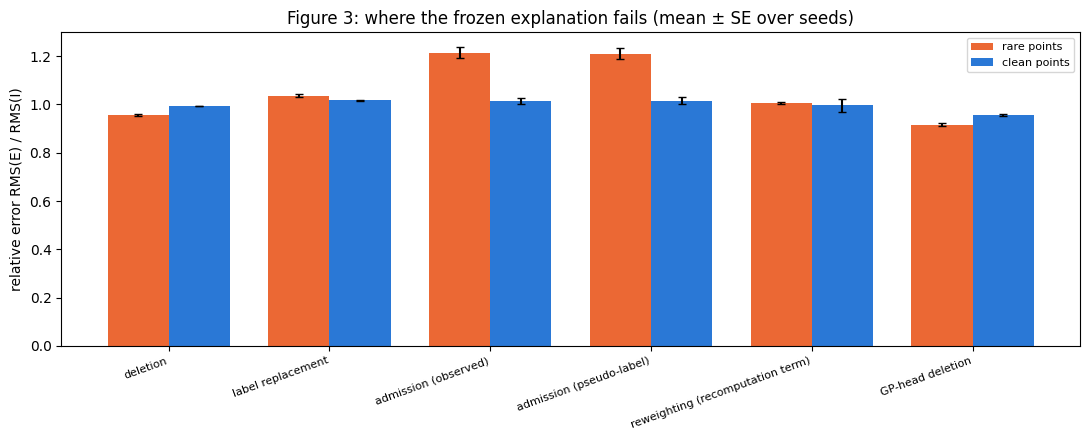

In [49]:
FIG3_SUMMARY = mean_and_se(pd.DataFrame(FIG3), ["edit", "points"], ["relative_rms"])
display(mean_se_table(FIG3_SUMMARY, ["edit", "points"], ["relative_rms"]))
edits = list(dict.fromkeys(row["edit"] for row in FIG3))
fig, ax = plt.subplots(figsize=(11, 4.5))
for j, (name, colour) in enumerate([("rare", "#eb6834"), ("clean", "#2a78d6")]):
    rows = FIG3_SUMMARY[FIG3_SUMMARY.points == name].set_index("edit").reindex(edits)
    ax.bar(np.arange(len(edits)) + (j - 0.5) * 0.38, rows["relative_rms_mean"], 0.38, yerr=rows["relative_rms_se"],
           capsize=3, color=colour, label=f"{name} points")
ax.set_xticks(range(len(edits)))
ax.set_xticklabels(edits, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("relative error RMS(E) / RMS(I)")
ax.legend(fontsize=8)
ax.set_title("Figure 3: where the frozen explanation fails (mean ± SE over seeds)")
plt.tight_layout()
plt.show()

**How to read this:** one pair of bars per kind of context edit: the typical error of the frozen explanation relative to the size of the true effect, for edits of rare and of clean points (for reweighting: rare and clean *queries*, since no single point is edited). 0 means the head explanation predicts the edit exactly; values near 1 mean it misses about as much as the effect itself.

# 10. Interpretation (fill in after the full run)

Guardrails. Check each before writing:
- [ ] A small error supports the head explanation **only on the audited contexts and edits**; it does not certify other edits (paper §4.2).
- [ ] A large error identifies an omitted representation response; it is **not** evidence that the recomputed predictor is worse.
- [ ] The frozen difficulty score is not label-honest (Section 2); conclusions about difficulty use the refit score.
- [ ] Pseudo-label admission results are not an admission policy (paper §4.3).
- [ ] Errors below the noise floor (0.7) are not interpreted; end-to-end rows are labelled as such.
- [ ] Comparisons with the other dataset keep the different failure mechanism in mind (under-representation here vs shortcut in Waterbirds).

## Does the frozen explanation predict deletions? (Section 3)

## Is it worse for rare points, and for which edits? (Sections 3.2, 4, figure 3)

## Context length (3.4)

## Head reweighting vs resampling (Section 5)

## GP head (Section 6)

## Limitations